In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [91]:
path = (r'C:\Users\mg441\pda_project\data')

In [92]:
users_df = pd.read_csv(path + r'\users.csv')

In [93]:
users_df['user_id'].nunique()

19050

In [94]:
users_df.isna().sum()

user_id                        0
signup_date                    0
acquisition_source             0
device_type                    0
campaign_id                 3801
signup_method                  0
gender                         0
age_group                      0
job_category                   0
state                          0
current_plan               13523
plan_start_date            13523
is_activated                   0
activation_date            15908
churn_date                  8308
cancel_reason              10494
total_sessions                 0
total_lessons_completed        0
last_active_date               0
dtype: int64

In [95]:
users_df['acquisition_source'].value_counts()

acquisition_source
google_ads              3816
organic                 3801
youtube                 3378
content_marketing       2746
meta_ads                2320
referral                1517
instagram_influencer    1472
Name: count, dtype: int64

In [96]:
users_df['device_type'].value_counts()

device_type
web        8516
ios        5660
android    4874
Name: count, dtype: int64

In [97]:
users_df['job_category'].value_counts()

job_category
student         3810
marketing       3387
design          2264
office_admin    2252
sales           1942
developer       1570
finance         1564
other           1305
hr               956
Name: count, dtype: int64

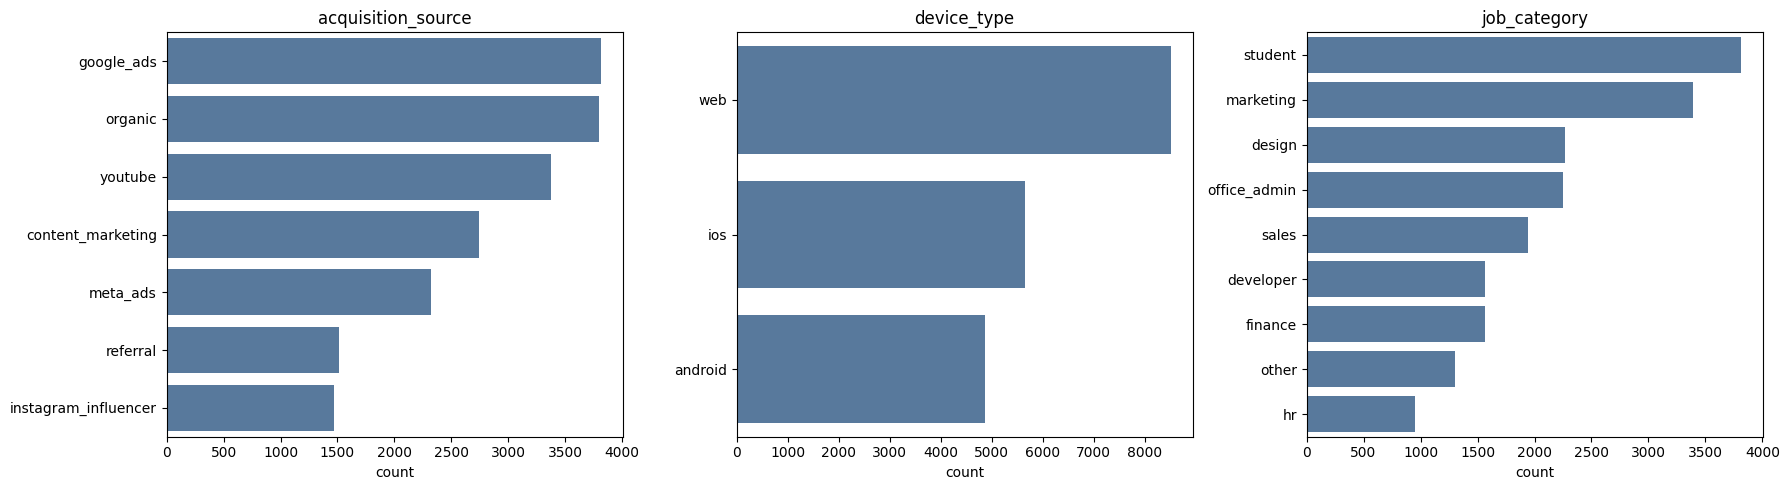

In [98]:
cols = ["acquisition_source", "device_type", "job_category"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, cols):
    counts = users_df[col].value_counts()
    sns.barplot(x=counts.values, y=counts.index, ax=ax, color="#4c78a8")
    ax.set_title(col)
    ax.set_xlabel("count")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

In [99]:
users_df['age_group'].value_counts()

age_group
25-29    6587
30-34    5379
20-24    2894
35-39    2850
40+      1340
Name: count, dtype: int64

In [100]:
users_df['gender'].value_counts()

gender
female    10637
male       7862
other       551
Name: count, dtype: int64

In [101]:
users_df.loc[users_df['gender']=='other']

,user_id,signup_date,acquisition_source,device_type,campaign_id,signup_method,gender,age_group,job_category,state,current_plan,plan_start_date,is_activated,activation_date,churn_date,cancel_reason,total_sessions,total_lessons_completed,last_active_date
1,U-00002,2024-03-18,youtube,web,CMP-010,google,other,25-29,sales,churned,NaN,NaN,False,NaN,2024-04-07,NaN,0,0,2024-04-07
39,U-00040,2024-10-16,content_marketing,web,CMP-008,email,other,25-29,sales,resurrected,monthly_basic,2025-04-29,False,NaN,2024-12-12,NaN,12,5,2025-05-23
84,U-00085,2024-08-30,google_ads,android,CMP-003,kakao,other,25-29,sales,churned,NaN,NaN,False,NaN,2024-10-21,NaN,0,0,2024-10-21
85,U-00086,2024-06-28,organic,web,NaN,email,other,25-29,developer,active,annual_basic,2024-07-05,True,2025-01-16,NaN,NaN,82,55,2025-05-25
139,U-00140,2024-05-18,meta_ads,android,CMP-005,kakao,other,30-34,sales,resurrected,monthly_basic,2025-05-22,False,NaN,2024-06-21,NaN,0,4,2025-05-22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18981,U-18982,2025-05-25,instagram_influencer,ios,CMP-013,kakao,other,30-34,marketing,trialing,NaN,NaN,False,NaN,NaN,NaN,3,0,2025-05-25
19036,U-19037,2025-05-25,content_marketing,android,CMP-007,kakao,other,20-24,finance,trialing,NaN,NaN,False,NaN,NaN,NaN,1,1,2025-05-25
19038,U-19039,2025-05-25,google_ads,web,CMP-002,email,other,25-29,hr,trialing,NaN,NaN,False,NaN,NaN,NaN,1,0,2025-05-25
19042,U-19043,2025-05-25,youtube,ios,CMP-011,kakao,other,20-24,design,trialing,NaN,NaN,False,NaN,NaN,NaN,2,0,2025-05-25


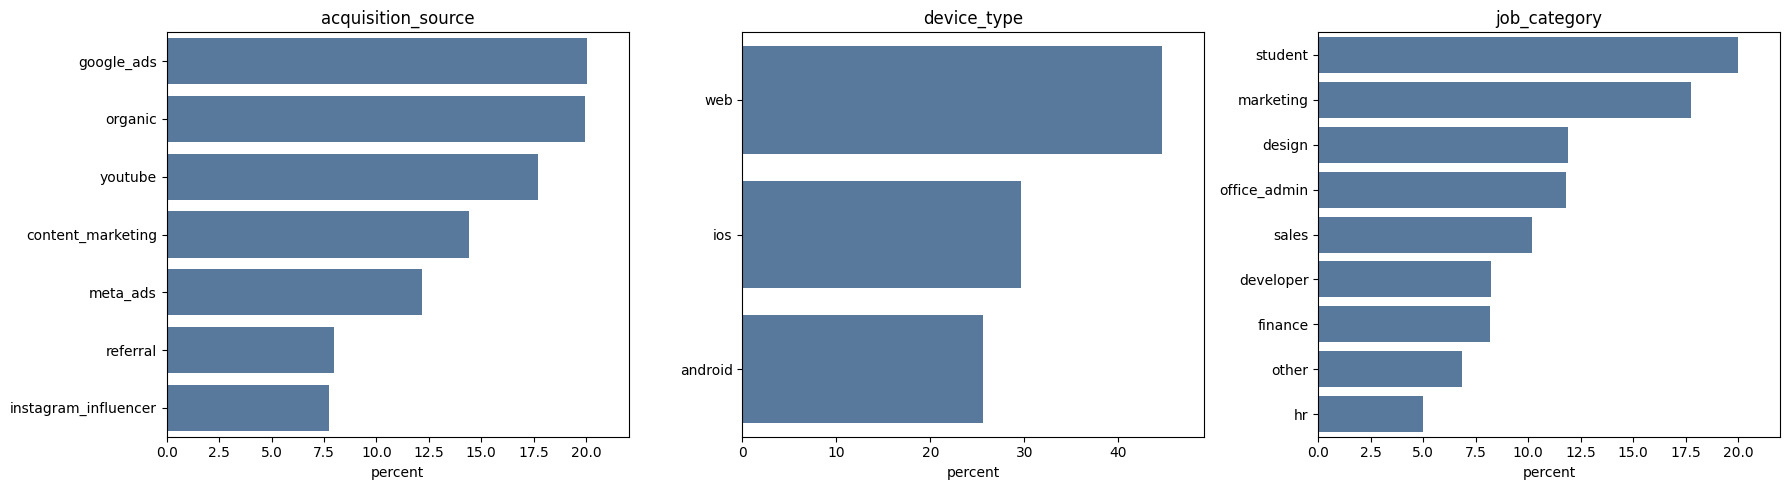

In [102]:
cols = ["acquisition_source", "device_type", "job_category"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, cols):
    pct = users_df[col].value_counts(normalize=True) * 100
    sns.barplot(x=pct.values, y=pct.index, ax=ax, color="#4c78a8")
    ax.set_title(col)
    ax.set_xlabel("percent")
    ax.set_ylabel("")
    ax.set_xlim(0, pct.max() * 1.1)

plt.tight_layout()
plt.show()

In [103]:
def print_count_percent(df, col, name=None):
    counts = df[col].value_counts(dropna=False)
    pct = df[col].value_counts(normalize=True, dropna=False) * 100
    out = (
        pd.DataFrame({"count": counts, "percent": pct})
        .assign(percent=lambda d: d["percent"].round(2))
    )
    print(f"\n=== {name or col} ===")
    for idx, row in out.iterrows():
        label = str(idx)
        print(f"{label:<25} {int(row['count']):>5} ({row['percent']:.2f}%)")

print_count_percent(users_df, "acquisition_source", "acquisition_source")
print_count_percent(users_df, "device_type", "device_type")
print_count_percent(users_df, "job_category", "job_category")
print_count_percent(users_df, "gender", "gender")
print_count_percent(users_df, "age_group", "age_group")
print_count_percent(users_df, "state", "state")




=== acquisition_source ===
google_ads                 3816 (20.03%)
organic                    3801 (19.95%)
youtube                    3378 (17.73%)
content_marketing          2746 (14.41%)
meta_ads                   2320 (12.18%)
referral                   1517 (7.96%)
instagram_influencer       1472 (7.73%)

=== device_type ===
web                        8516 (44.70%)
ios                        5660 (29.71%)
android                    4874 (25.59%)

=== job_category ===
student                    3810 (20.00%)
marketing                  3387 (17.78%)
design                     2264 (11.88%)
office_admin               2252 (11.82%)
sales                      1942 (10.19%)
developer                  1570 (8.24%)
finance                    1564 (8.21%)
other                      1305 (6.85%)
hr                          956 (5.02%)

=== gender ===
female                    10637 (55.84%)
male                       7862 (41.27%)
other                       551 (2.89%)

=== age_group ===

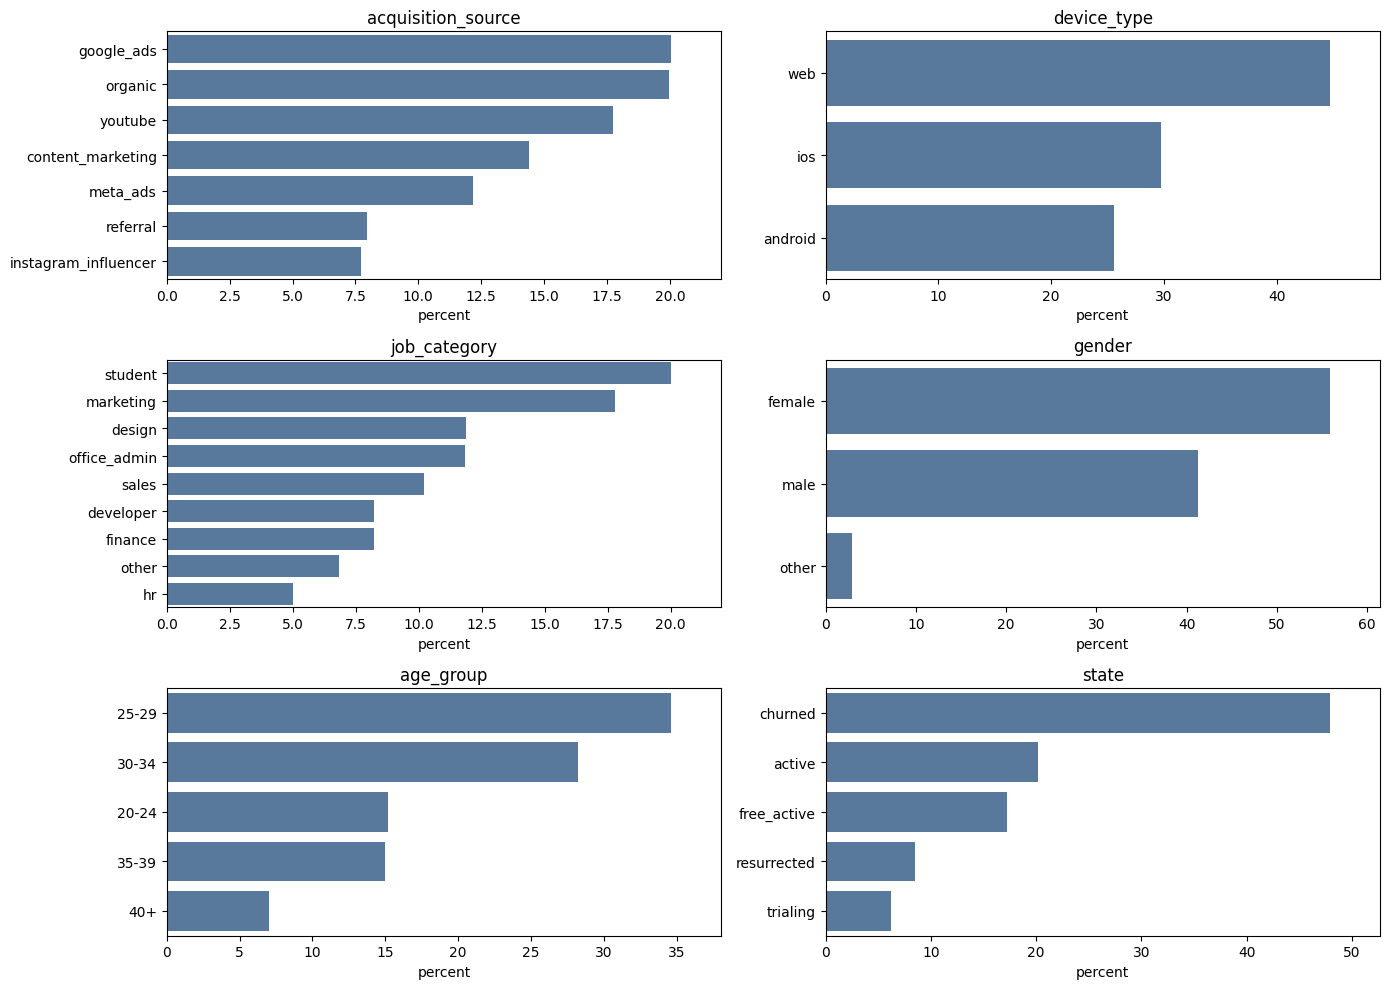

In [104]:
cols = ["acquisition_source","device_type", "job_category", "gender", "age_group","state"]

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    pct = users_df[col].value_counts(normalize=True, dropna=False) * 100
    sns.barplot(x=pct.values, y=pct.index.astype(str), ax=ax, color="#4c78a8")
    ax.set_title(col)
    ax.set_xlabel("percent")
    ax.set_ylabel("")
    ax.set_xlim(0, pct.max() * 1.1)

plt.tight_layout()
plt.show()


=== gender x acquisition_source ===
    gender              category  count    percent
1   female            google_ads   2148  20.193664
4   female               organic   2135  20.071449
6   female               youtube   1878  17.655354
0   female     content_marketing   1519  14.280342
3   female              meta_ads   1295  12.174485
2   female  instagram_influencer    834   7.840557
5   female              referral    828   7.784150
11    male               organic   1559  19.829560
8     male            google_ads   1553  19.753243
13    male               youtube   1410  17.934368
7     male     content_marketing   1147  14.589163
10    male              meta_ads    954  12.134317
12    male              referral    649   8.254897
9     male  instagram_influencer    590   7.504452

=== gender x device_type ===
   gender category  count    percent
2  female      web   4764  44.787064
1  female      ios   3156  29.670020
0  female  android   2717  25.542916
5    male      web  

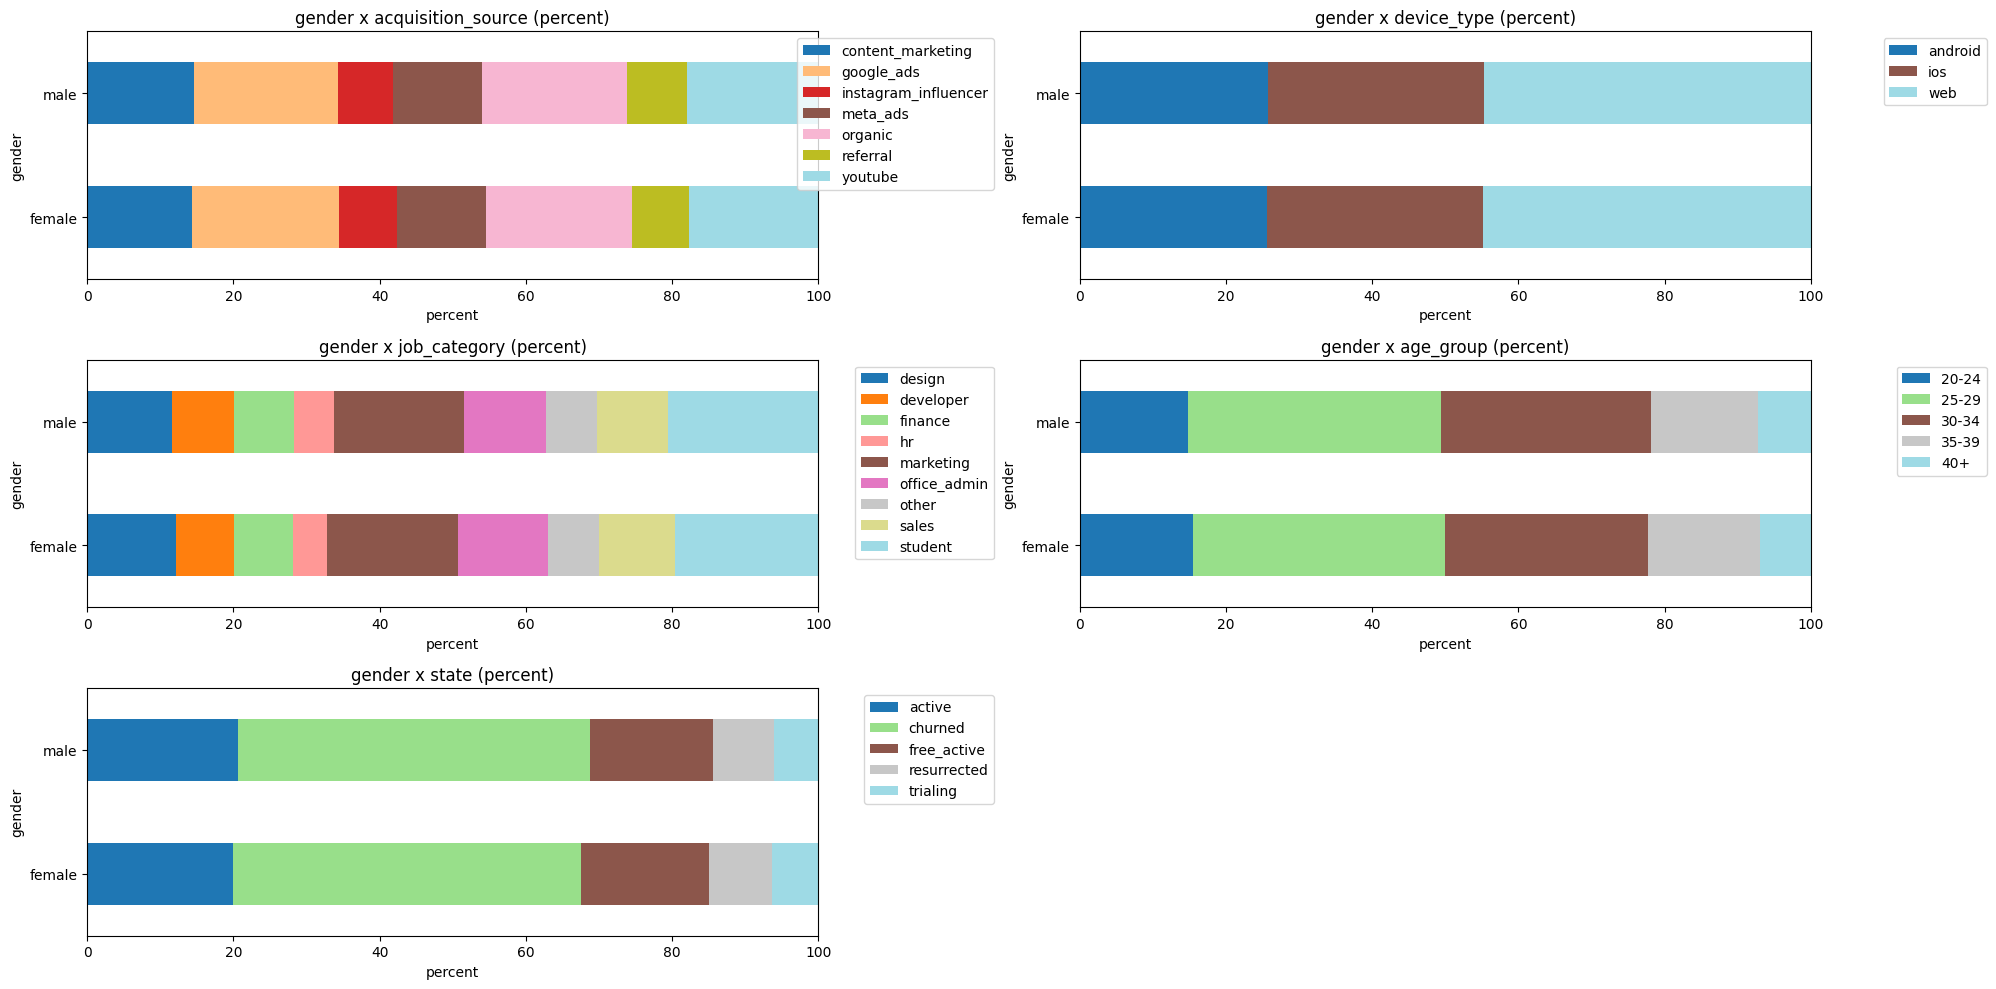

In [105]:
cols = ["acquisition_source", "device_type", "job_category", "age_group", "state"]

# gender == 'other' 제외
filtered = users_df[users_df["gender"].str.lower() != "other"].copy()

def count_pct_by_gender(df, col):
    counts = pd.crosstab(df["gender"], df[col], dropna=False)
    pct = pd.crosstab(df["gender"], df[col], normalize="index", dropna=False) * 100
    out = (
        counts.stack().rename("count")
        .to_frame()
        .join(pct.stack().rename("percent"))
        .reset_index()
        .rename(columns={"gender": "gender", col: "category"})
        .sort_values(["gender", "count"], ascending=[True, False])
    )
    return out, counts, pct

# 실제값 + 비율 출력
for col in cols:
    out, _, _ = count_pct_by_gender(filtered, col)
    print(f"\n=== gender x {col} ===")
    print(out)

# 시각화 (성별별 비율)
fig, axes = plt.subplots(3, 2, figsize=(20, 10))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    _, _, pct = count_pct_by_gender(filtered, col)
    pct.plot(kind="barh", stacked=True, ax=ax, colormap="tab20")
    ax.set_title(f"gender x {col} (percent)")
    ax.set_xlabel("percent")
    ax.set_ylabel("gender")
    ax.set_xlim(0, 100)
    ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.0))

for ax in axes[len(cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [106]:
active = users_df[users_df["is_activated"] == True].copy()


combo = (
    active
    .groupby(["gender", "age_group", "job_category", "acquisition_source", "device_type"])
    .size()
    .reset_index(name="count")
)

combo["percent_active"] = (combo["count"] / combo["count"].sum() * 100).round(2)
combo = combo.sort_values("count", ascending=False)

print(combo.head(20))


     gender age_group  job_category acquisition_source device_type  count  \
247  female     25-29       student            organic         web     23   
253  female     25-29       student            youtube         web     22   
179  female     25-29     marketing            organic         web     19   
185  female     25-29     marketing            youtube         web     19   
386  female     30-34       student            organic         web     17   
197  female     25-29  office_admin            organic         web     15   
246  female     25-29       student            organic         ios     14   
265  female     30-34        design            organic         web     13   
806    male     25-29       student            organic         web     13   
810    male     25-29       student            youtube         ios     13   
202  female     25-29  office_admin            youtube         web     12   
391  female     30-34       student            youtube         ios     12   

In [107]:
base = users_df.copy()


combo = (
    base
    .groupby(["gender", "age_group", "job_category", "acquisition_source", "device_type"])
    .size()
    .reset_index(name="count")
)

combo["percent_base"] = (combo["count"] / combo["count"].sum() * 100).round(2)
combo = combo.sort_values("count", ascending=False)

print(combo.head(20))


      gender age_group job_category acquisition_source device_type  count  \
360   female     25-29      student         google_ads         web     70   
369   female     25-29      student            organic         web     67   
276   female     25-29    marketing         google_ads         web     61   
557   female     30-34      student            organic         web     60   
285   female     25-29    marketing            organic         web     56   
375   female     25-29      student            youtube         web     56   
368   female     25-29      student            organic         ios     55   
291   female     25-29    marketing            youtube         web     55   
273   female     25-29    marketing  content_marketing         web     55   
547   female     30-34      student         google_ads         ios     52   
548   female     30-34      student         google_ads         web     50   
192   female     25-29       design         google_ads         web     50   

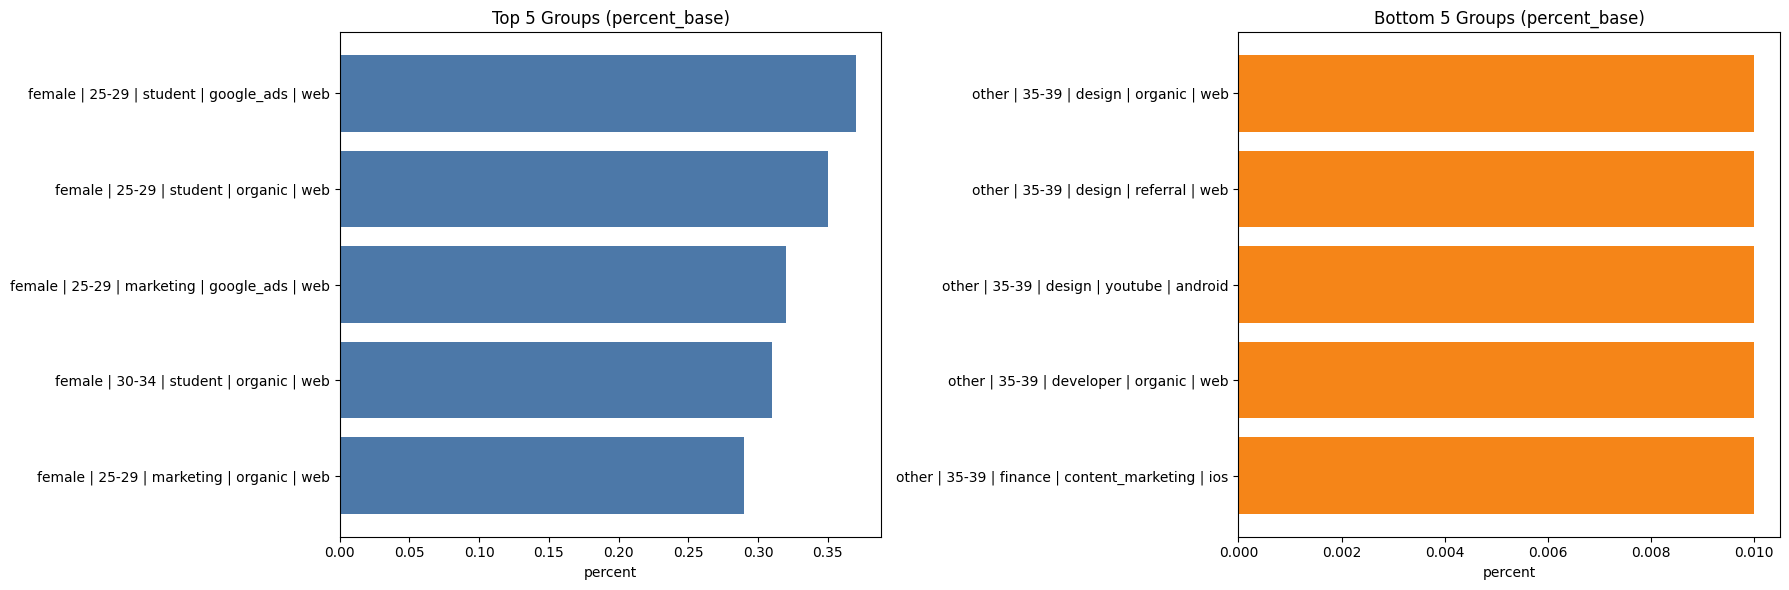

In [108]:
# 상위 5 / 하위 5
top5 = combo.head(5).copy()
bottom5 = combo.tail(5).copy()

def make_label(df):
    return (
        df["gender"].astype(str) + " | " +
        df["age_group"].astype(str) + " | " +
        df["job_category"].astype(str) + " | " +
        df["acquisition_source"].astype(str) + " | " +
        df["device_type"].astype(str)
    )

top5["label"] = make_label(top5)
bottom5["label"] = make_label(bottom5)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 상위 5
axes[0].barh(top5["label"], top5["percent_base"], color="#4c78a8")
axes[0].invert_yaxis()
axes[0].set_title("Top 5 Groups (percent_base)")
axes[0].set_xlabel("percent")

# 하위 5
axes[1].barh(bottom5["label"], bottom5["percent_base"], color="#f58518")
axes[1].invert_yaxis()
axes[1].set_title("Bottom 5 Groups (percent_base)")
axes[1].set_xlabel("percent")

plt.tight_layout()
plt.show()

In [162]:
events_df = pd.read_csv(r"c:\Users\mg441\pda_project\data\event_logs.csv")

# inner join
# df = users.merge(events, on="user_id", how="inner")

# left join (유저 기준, 이벤트 없으면 NaN)
df = events_df.merge(users_df, on="user_id", how="left")

df['event_name'].columns

KeyboardInterrupt: 

In [110]:
df2 = df.copy()


In [171]:
df2['event_name'].value_counts()

event_name
page_viewed                  252508
session_ended                202084
session_started              202071
lesson_started               109568
lesson_completed             107064
course_detail_viewed          74520
course_searched               47343
onboarding_step_completed     29062
pricing_page_viewed           15088
signup_completed              14119
quiz_submitted                13186
onboarding_started            12689
course_wishlisted             11016
onboarding_completed           8396
plan_selected                  7546
referral_sent                  6066
chat_started                   5423
checkout_started               3563
course_completed               2472
review_submitted               1650
certificate_downloaded          508
Name: count, dtype: int64

In [111]:
import plotly.graph_objects as go  # 퍼널 시각화용

## 퍼널 정의 
# 목표: 유료 구독 
# 과정: 세션 시작 → 강의 검색 → 강의 상세 페이지 조회 → 강의 시작 → 강의 완료 → 요금제 선택 → 결제 시작 

# 퍼널 순서를 담고 있는 리스트 정의
FUNNEL_EVENTS = ['session_started', 'signup_completed','lesson_started', 'lesson_completed','pricing_page_viewed' ,'plan_selected', 'checkout_started']

# 데이터프레임명 (log) 수정하시면 됩니당
filtered = df2[df2['event_name'].isin(FUNNEL_EVENTS)]
filtered

# 1) 이벤트 별로 분할
grouped = filtered.groupby('event_name')

# 2) 단계별 고유한 사용자 수 집계
aggregated = grouped['user_id'].nunique().reindex(FUNNEL_EVENTS)
funnel_df = aggregated.reset_index()
funnel_df.columns = ['stage','user_cnt']
print(funnel_df.shape)
funnel_df

# 3) 시각화 
fig = go.Figure(go.Funnel(
    y = funnel_df['stage'],       # 단계명
    x = funnel_df['user_cnt'],  # 사용자 수

    textposition = "inside",
    textinfo = "value+percent initial+percent previous",

    opacity = 0.85,
    marker = {
        "color": ["#4E79A7", "#F28E2B", "#E15759", "#76B7B2", "#59A14F"],
        "line": {"width": 1, "color": "#333333"}
    },
    connector = {
        "line": {"color": "gray", "dash": "dot", "width": 2}
    }
))

fig.update_layout(
    title={
        'text': "사용자 구매 전환 퍼널 분석",
        'y': 0., 'x': 0.5,
        'xanchor': 'center', 'yanchor': 'top'
    },
    font={'family': "Arial, sans-serif", 'size': 12, 'color': "black"}
)

fig.show()

(7, 2)


In [112]:
# df.to_csv(r"c:\Users\mg441\pda_project\data\event_users_join.csv", index=False)

In [113]:
events_df['user_id'].nunique()

17020

NameError: name 'funnel_join2' is not defined

In [115]:
events_df

,user_id,session_id,event_name,event_timestamp,device_type,location,event_sequence,page_name,course_id,lesson_id,event_properties
0,U-02330,S-d93df4dcbfa3,session_started,2025-01-06T00:11:00,ios,South Korea,1,NaN,NaN,NaN,NaN
1,U-02330,S-d93df4dcbfa3,page_viewed,2025-01-06T00:13:44,ios,South Korea,2,home,NaN,NaN,NaN
2,U-02330,S-d93df4dcbfa3,course_searched,2025-01-06T00:15:43,ios,South Korea,3,NaN,NaN,NaN,"{""search_keyword"": ""chatgpt"", ""result_count"": 7}"
3,U-02330,S-d93df4dcbfa3,session_ended,2025-01-06T00:18:28,ios,South Korea,4,NaN,NaN,NaN,NaN
4,U-00679,S-9f84670f02e6,session_started,2025-01-06T03:19:54,web,South Korea,1,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
1125937,U-13521,S-0d512131d469,session_ended,2025-05-26T00:07:08,ios,South Korea,5,NaN,NaN,NaN,NaN
1125938,U-18172,S-43c33d34aa4e,session_ended,2025-05-26T00:07:08,web,South Korea,6,NaN,NaN,NaN,NaN
1125939,U-18914,S-88114cf97494,session_ended,2025-05-26T00:07:32,ios,South Korea,6,NaN,NaN,NaN,NaN
1125940,U-16122,S-4a30b2a881db,session_ended,2025-05-26T00:07:41,web,South Korea,6,NaN,NaN,NaN,NaN


In [116]:
df = pd.read_csv(path + r'/funnel_join2.csv')

In [117]:
df.columns

#로그 데이터 날짜 min max 사이에 있는 것들

Index(['user_id', 'session_id', 'event_name', 'event_timestamp', 'device_type',
       'location', 'event_sequence', 'page_name', 'course_id', 'lesson_id',
       'event_properties'],
      dtype='object')

In [118]:
df['event_name'].value_counts()

event_name
page_viewed                  156464
session_started              130903
session_ended                130892
lesson_started                69703
lesson_completed              67216
course_detail_viewed          46205
course_searched               29420
onboarding_step_completed     29062
signup_completed              14119
pricing_page_viewed           14040
onboarding_started            12689
onboarding_completed           8396
quiz_submitted                 8259
plan_selected                  7011
course_wishlisted              6751
subscribe                      5539
chat_started                   3376
checkout_started               3311
referral_sent                  3306
course_completed               1307
review_submitted                765
certificate_downloaded          230
Name: count, dtype: int64

In [119]:
df["event_timestamp"] = pd.to_datetime(df["event_timestamp"], errors="coerce")

subscribe_ts = df.loc[df["event_name"] == "subscribe", "event_timestamp"]

subscribe_min = subscribe_ts.min()
subscribe_max = subscribe_ts.max()

subscribe_min, subscribe_max


(Timestamp('2024-03-08 00:00:00'), Timestamp('2025-03-06 00:00:00'))

In [120]:
signup_ts = df.loc[df["event_name"] == "signup_completed", "event_timestamp"]

signup_min = signup_ts.min()
signup_max = signup_ts.max()

signup_min, signup_max

(Timestamp('2025-01-06 08:24:51'), Timestamp('2025-05-25 23:54:07'))

In [121]:
# 가입 완료한 유저 집합
signup_users = set(df.loc[df["event_name"] == "signup_completed", "user_id"])

# subscribe 중에서 그 유저들만
result = df[
    (df["event_name"] == "subscribe") &
    (df["user_id"].isin(signup_users))
]

result


,user_id,session_id,event_name,event_timestamp,device_type,location,event_sequence,page_name,course_id,lesson_id,event_properties
744197,U-05003,NaN,subscribe,2025-01-14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
744198,U-05005,NaN,subscribe,2025-01-14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
744199,U-05006,NaN,subscribe,2025-01-14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
744200,U-05018,NaN,subscribe,2025-01-14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
744201,U-05022,NaN,subscribe,2025-01-14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
748959,U-17855,NaN,subscribe,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
748960,U-17856,NaN,subscribe,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
748961,U-17860,NaN,subscribe,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
748962,U-17861,NaN,subscribe,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [122]:
signup_users = df.loc[df["event_name"] == "signup_completed", "user_id"]

df_with_signup = df[df["user_id"].isin(signup_users)]


In [176]:
## 퍼널 정의
# 목표:
# 과정:

# 퍼널 순서를 담고 있는 리스트 정의
# FUNNEL_EVENTS = ['signup_completed', 'lesson_started', '', 'subscribe', 'referral_sent']
FUNNEL_EVENTS = ['signup_completed', 'lesson_started', 'lesson_completed','pricing_page_viewed', 'plan_selected','checkout_started']
#'onboarding_completed',  'checkout_started',

# 해당 퍼널만 선택
filtered = df_with_signup[df_with_signup['event_name'].isin(FUNNEL_EVENTS)]
filtered

# 1) 이벤트 별로 분할
grouped = filtered.groupby('event_name')

# 2) 단계별 고유한 사용자 수 집계
aggregated = grouped['user_id'].nunique().reindex(FUNNEL_EVENTS)
funnel_df = aggregated.reset_index()
funnel_df.columns = ['stage','user_cnt']
print(funnel_df.shape)
funnel_df

# 3) 시각화
fig = go.Figure(go.Funnel(
    y = funnel_df['stage'],       # 단계명
    x = funnel_df['user_cnt'],  # 사용자 수

    textposition = "inside",
    textinfo = "value+percent initial+percent previous",

    opacity = 0.85,
    marker = {
        "color": ["#4E79A7", "#F28E2B", "#E15759", "#76B7B2", "#59A14F"],
        "line": {"width": 1, "color": "#333333"}
    },
    connector = {
        "line": {"color": "gray", "dash": "dot", "width": 2}
    }
))

fig.update_layout(
    title={
        'text': "사용자 구매 전환 퍼널 분석",
        'y': 0., 'x': 0.5,
        'xanchor': 'center', 'yanchor': 'top'
    },
    font={'family': "Arial, sans-serif", 'size': 18, 'color': "black"}
)

fig.show()

(6, 2)


In [179]:
## 퍼널 정의
# 목표:
# 과정:

# 퍼널 순서를 담고 있는 리스트 정의
# FUNNEL_EVENTS = ['signup_completed', 'lesson_started', '', 'subscribe', 'referral_sent']
FUNNEL_EVENTS = ['session_started', 'onboarding_started', 'onboarding_step_completed','onboarding_completed']
#'onboarding_completed',  'checkout_started',

# 해당 퍼널만 선택
filtered = df_with_signup[df_with_signup['event_name'].isin(FUNNEL_EVENTS)]
filtered

# 1) 이벤트 별로 분할
grouped = filtered.groupby('event_name')

# 2) 단계별 고유한 사용자 수 집계
aggregated = grouped['user_id'].nunique().reindex(FUNNEL_EVENTS)
funnel_df = aggregated.reset_index()
funnel_df.columns = ['stage','user_cnt']
print(funnel_df.shape)
funnel_df

# 3) 시각화
fig = go.Figure(go.Funnel(
    y = funnel_df['stage'],       # 단계명
    x = funnel_df['user_cnt'],  # 사용자 수

    textposition = "inside",
    textinfo = "value+percent initial+percent previous",

    opacity = 0.85,
    marker = {
        "color": ["#4E79A7", "#F28E2B", "#E15759", "#76B7B2", "#59A14F"],
        "line": {"width": 1, "color": "#333333"}
    },
    connector = {
        "line": {"color": "gray", "dash": "dot", "width": 2}
    }
))

fig.update_layout(
    title={
        'text': "사용자 구매 전환 퍼널 분석",
        'y': 0., 'x': 0.5,
        'xanchor': 'center', 'yanchor': 'top'
    },
    font={'family': "Arial, sans-serif", 'size': 18, 'color': "black"}
)

fig.show()

(4, 2)


In [180]:
## 퍼널 정의
# 목표:
# 과정:

# 퍼널 순서를 담고 있는 리스트 정의
# FUNNEL_EVENTS = ['signup_completed', 'lesson_started', '', 'subscribe', 'referral_sent']
FUNNEL_EVENTS = ['lesson_started', 'lesson_completed', 'quiz_submitted','course_completed','certificate_downloaded']
#'onboarding_completed',  'checkout_started',

# 해당 퍼널만 선택
filtered = df_with_signup[df_with_signup['event_name'].isin(FUNNEL_EVENTS)]
filtered

# 1) 이벤트 별로 분할
grouped = filtered.groupby('event_name')

# 2) 단계별 고유한 사용자 수 집계
aggregated = grouped['user_id'].nunique().reindex(FUNNEL_EVENTS)
funnel_df = aggregated.reset_index()
funnel_df.columns = ['stage','user_cnt']
print(funnel_df.shape)
funnel_df

# 3) 시각화
fig = go.Figure(go.Funnel(
    y = funnel_df['stage'],       # 단계명
    x = funnel_df['user_cnt'],  # 사용자 수

    textposition = "inside",
    textinfo = "value+percent initial+percent previous",

    opacity = 0.85,
    marker = {
        "color": ["#4E79A7", "#F28E2B", "#E15759", "#76B7B2", "#59A14F"],
        "line": {"width": 1, "color": "#333333"}
    },
    connector = {
        "line": {"color": "gray", "dash": "dot", "width": 2}
    }
))

fig.update_layout(
    title={
        'text': "사용자 구매 전환 퍼널 분석",
        'y': 0., 'x': 0.5,
        'xanchor': 'center', 'yanchor': 'top'
    },
    font={'family': "Arial, sans-serif", 'size': 18, 'color': "black"}
)

fig.show()

(5, 2)


In [181]:
## 퍼널 정의
# 목표:
# 과정:

# 퍼널 순서를 담고 있는 리스트 정의
# FUNNEL_EVENTS = ['signup_completed', 'lesson_started', '', 'subscribe', 'referral_sent']
FUNNEL_EVENTS = ['session_started', 'signup_completed', 'course_detail_viewed','lesson_started','lesson_completed','plan_selected']
#'onboarding_completed',  'checkout_started',

# 해당 퍼널만 선택
filtered = df_with_signup[df_with_signup['event_name'].isin(FUNNEL_EVENTS)]
filtered

# 1) 이벤트 별로 분할
grouped = filtered.groupby('event_name')

# 2) 단계별 고유한 사용자 수 집계
aggregated = grouped['user_id'].nunique().reindex(FUNNEL_EVENTS)
funnel_df = aggregated.reset_index()
funnel_df.columns = ['stage','user_cnt']
print(funnel_df.shape)
funnel_df

# 3) 시각화
fig = go.Figure(go.Funnel(
    y = funnel_df['stage'],       # 단계명
    x = funnel_df['user_cnt'],  # 사용자 수

    textposition = "inside",
    textinfo = "value+percent initial+percent previous",

    opacity = 0.85,
    marker = {
        "color": ["#4E79A7", "#F28E2B", "#E15759", "#76B7B2", "#59A14F"],
        "line": {"width": 1, "color": "#333333"}
    },
    connector = {
        "line": {"color": "gray", "dash": "dot", "width": 2}
    }
))

fig.update_layout(
    title={
        'text': "사용자 구매 전환 퍼널 분석",
        'y': 0., 'x': 0.5,
        'xanchor': 'center', 'yanchor': 'top'
    },
    font={'family': "Arial, sans-serif", 'size': 18, 'color': "black"}
)

fig.show()

(6, 2)


In [124]:
df["event_timestamp"] = pd.to_datetime(df["event_timestamp"], errors="coerce")

# 유저별 첫 lesson_started 시점
first_lesson = (
    df.loc[df["event_name"] == "lesson_started"]
      .groupby("user_id")["event_timestamp"]
      .min()
)

# subscribe 없는 유저
sub_users = set(df.loc[df["event_name"] == "subscribe", "user_id"])
target_users = set(first_lesson.index) - sub_users

# 7일 이후에도 강의 이벤트가 있는 유저 찾기
lesson_events = df[df["event_name"].isin(["lesson_started", "lesson_completed"])]

def has_lesson_after_7d(u):
    if u not in first_lesson:
        return False
    cutoff = first_lesson[u] + pd.Timedelta(days=7)
    return (lesson_events["user_id"].eq(u) & (lesson_events["event_timestamp"] >= cutoff)).any()

users_after_7d = [u for u in target_users if has_lesson_after_7d(u)]

len(users_after_7d), users_after_7d[:10]


(2210,
 ['U-09970',
  'U-06446',
  'U-05217',
  'U-08726',
  'U-13735',
  'U-08897',
  'U-10367',
  'U-13990',
  'U-15151',
  'U-11832'])

In [125]:
import pandas as pd
import numpy as np

df_with_signup["event_timestamp"] = pd.to_datetime(df_with_signup["event_timestamp"], errors="coerce")

# 강의 관련 이벤트 정의 (원하는 이벤트로 조정 가능)
lesson_events = df_with_signup[df_with_signup["event_name"].isin(["lesson_started", "lesson_completed"])]

# 유저별 첫 강의 시작 시점
first_lesson = (
    lesson_events[lesson_events["event_name"] == "lesson_started"]
    .groupby("user_id")["event_timestamp"]
    .min()
)

# 유저별 마지막 강의 이벤트 시점
last_lesson = (
    lesson_events.groupby("user_id")["event_timestamp"]
    .max()
)

#첫 강의가 없는 유저 제외
valid_users = first_lesson.index.intersection(last_lesson.index)

# 이탈 주차(0주차부터 시작)
dropoff_week = (
    (last_lesson[valid_users] - first_lesson[valid_users])
    .dt.days
    .floordiv(7)
)

# #가입 후 1주차부터 이탈
# dropoff_week = (
#     (last_lesson[valid_users] - first_lesson[valid_users])
#     .dt.days
#     .floordiv(7)
# )

# dropoff_week = dropoff_week[dropoff_week >= 1]


# 주차별 이탈 수
dropoff_counts = dropoff_week.value_counts().sort_index()

dropoff_counts


C:\Users\mg441\AppData\Local\Temp\ipykernel_28152\3352331722.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



event_timestamp
0     6001
1      818
2      594
3      487
4      441
5      408
6      356
7      318
8      279
9      269
10     253
11     224
12     211
13     186
14     176
15     146
16     110
17     111
18      74
19      33
Name: count, dtype: int64

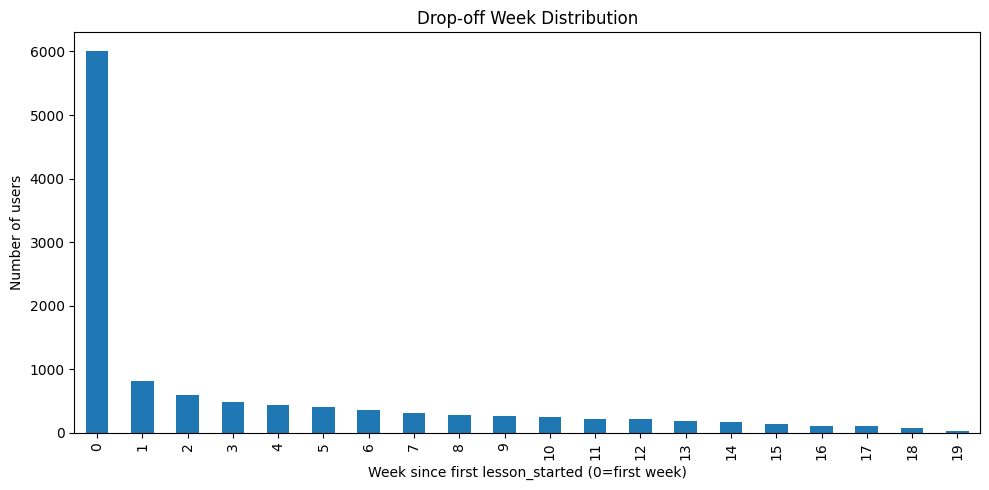

In [126]:
import matplotlib.pyplot as plt

# dropoff_counts가 Series라고 가정
plt.figure(figsize=(10, 5))
dropoff_counts.plot(kind="bar")
plt.title("Drop-off Week Distribution")
plt.xlabel("Week since first lesson_started (0=first week)")
plt.ylabel("Number of users")
plt.tight_layout()
plt.show()


C:\Users\mg441\AppData\Local\Temp\ipykernel_28152\1711028298.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



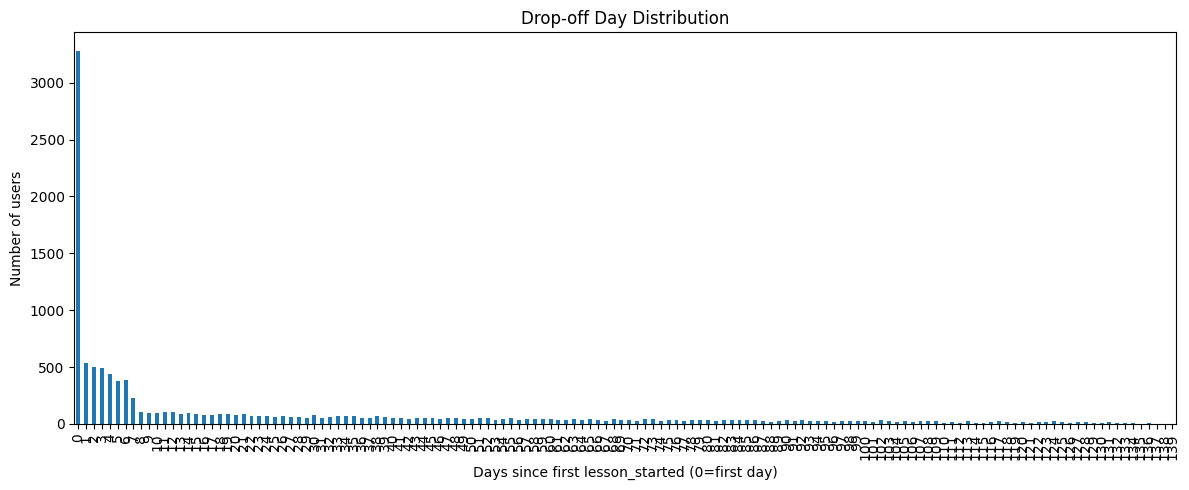

In [127]:
df_with_signup["event_timestamp"] = pd.to_datetime(df_with_signup["event_timestamp"], errors="coerce")

lesson_events = df_with_signup[df_with_signup["event_name"].isin(["lesson_started", "lesson_completed"])]

first_lesson = (
    lesson_events[lesson_events["event_name"] == "lesson_started"]
    .groupby("user_id")["event_timestamp"]
    .min()
)

last_lesson = (
    lesson_events.groupby("user_id")["event_timestamp"]
    .max()
)

valid_users = first_lesson.index.intersection(last_lesson.index)

# 이탈 일차(0일부터)
dropoff_day = (
    (last_lesson[valid_users] - first_lesson[valid_users])
    .dt.days
)

# 일별 이탈 수
dropoff_counts_day = dropoff_day.value_counts().sort_index()

# 시각화
plt.figure(figsize=(12, 5))
dropoff_counts_day.plot(kind="bar")
plt.title("Drop-off Day Distribution")
plt.xlabel("Days since first lesson_started (0=first day)")
plt.ylabel("Number of users")
plt.tight_layout()
plt.show()


In [128]:
dropoff_counts_day


event_timestamp
0      3279
1       532
2       501
3       491
4       435
       ... 
135       4
136       6
137       3
138       4
139       2
Name: count, Length: 140, dtype: int64

In [129]:
# dropoff_counts_day: 일별 이탈 수 (Series) 가정
dropoff_table = dropoff_counts_day.rename("count").to_frame()

total = dropoff_table["count"].sum()
dropoff_table["ratio"] = (dropoff_table["count"] / total * 100).round(2)

# Total 행 추가
total_row = pd.DataFrame({"count": [total], "ratio": [100.0]}, index=["Total"])
dropoff_table = pd.concat([dropoff_table, total_row])

dropoff_table.head(10)


,count,ratio
0,3279,28.53
1,532,4.63
2,501,4.36
3,491,4.27
4,435,3.78
5,379,3.30
6,384,3.34
7,224,1.95
8,107,0.93
9,95,0.83


In [130]:

df_with_signup["event_timestamp"] = pd.to_datetime(df_with_signup["event_timestamp"], errors="coerce")

# 강의 이벤트 정의
lesson_events = df_with_signup[df_with_signup["event_name"].isin(["lesson_started", "lesson_completed"])]

# 유저별 첫 lesson_started
first_lesson = (
    lesson_events[lesson_events["event_name"] == "lesson_started"]
    .groupby("user_id")["event_timestamp"]
    .min()
    .rename("first_lesson")
)

# first_lesson 붙이기
le = lesson_events.merge(first_lesson, on="user_id", how="inner")

# 주차 계산
le["week"] = ((le["event_timestamp"] - le["first_lesson"]).dt.days // 7)

# 0~3주차 모두 있는 유저
required_weeks = {0, 1, 2, 3}

users_4week = (
    le.groupby("user_id")["week"]
      .apply(lambda s: required_weeks.issubset(set(s.dropna().astype(int))))
)

users_4week = users_4week[users_4week].index.tolist()

users_4week[:10], len(users_4week)

C:\Users\mg441\AppData\Local\Temp\ipykernel_28152\417607941.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



(['U-05005',
  'U-05018',
  'U-05035',
  'U-05041',
  'U-05043',
  'U-05047',
  'U-05048',
  'U-05054',
  'U-05059',
  'U-05075'],
 1129)

In [131]:
# 12주 연속 (0~11주차)
required_weeks = set(range(12))

users_12week = (
    le.groupby("user_id")["week"]
      .apply(lambda s: required_weeks.issubset(set(s.dropna().astype(int))))
)

users_12week = users_12week[users_12week].index.tolist()

users_12week[:10], len(users_12week)


(['U-05005',
  'U-05018',
  'U-05041',
  'U-05047',
  'U-05054',
  'U-05059',
  'U-05075',
  'U-05175',
  'U-05252',
  'U-05269'],
 169)

In [132]:
# le: user_id, week 컬럼 존재한다고 가정
user_week_sets = le.groupby("user_id")["week"].apply(lambda s: set(s.dropna().astype(int)))

counts = {}
for k in range(1, 13):  # 1~12주차
    required = set(range(k))  # 0..k-1
    counts[k] = sum(required.issubset(weeks) for weeks in user_week_sets)

counts


{1: 11495,
 2: 3292,
 3: 1745,
 4: 1129,
 5: 802,
 6: 619,
 7: 493,
 8: 393,
 9: 324,
 10: 263,
 11: 213,
 12: 169}

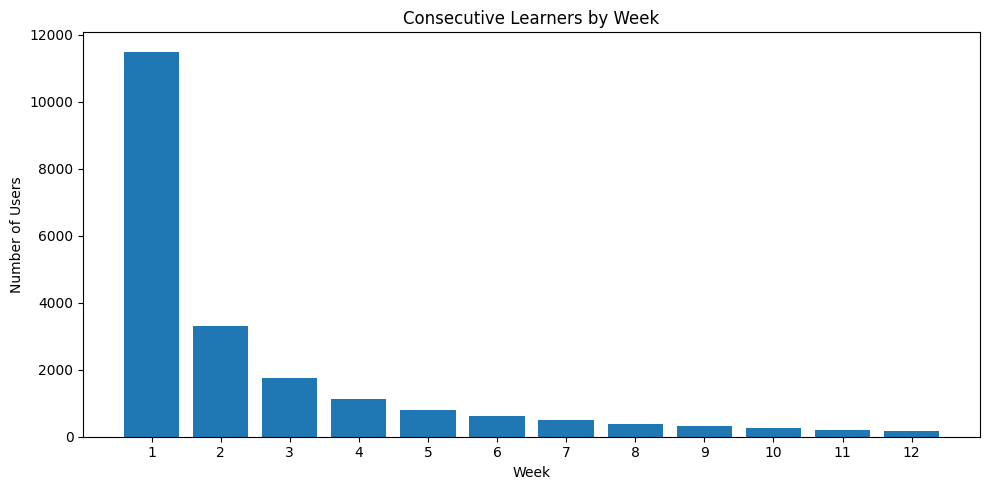

In [133]:

# counts: {주차: 유저수} dict
weeks = list(counts.keys())
users = list(counts.values())

plt.figure(figsize=(10, 5))
plt.bar(weeks, users)
plt.title("Consecutive Learners by Week")
plt.xlabel("Week")
plt.ylabel("Number of Users")
plt.xticks(weeks)
plt.tight_layout()
plt.show()


In [134]:
import pandas as pd

df_with_signup["event_timestamp"] = pd.to_datetime(df_with_signup["event_timestamp"], errors="coerce")

# 1) lesson_started 기반 2주 연속 유저 정의
lesson_started = df_with_signup[df_with_signup["event_name"] == "lesson_started"]

first_lesson = (
    lesson_started.groupby("user_id")["event_timestamp"]
    .min()
    .rename("first_lesson")
)

le = lesson_started.merge(first_lesson, on="user_id", how="inner")
le["week"] = ((le["event_timestamp"] - le["first_lesson"]).dt.days // 7)

required_weeks = {0, 1}
user_weeks = le.groupby("user_id")["week"].apply(lambda s: set(s.dropna().astype(int)))
retain_users = set(user_weeks[user_weeks.apply(lambda w: required_weeks.issubset(w))].index)

# 전체 유저는 df_with_signup 기준
all_users = set(df_with_signup["user_id"].dropna().unique())
churn_users = all_users - retain_users

C:\Users\mg441\AppData\Local\Temp\ipykernel_28152\2295267081.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [135]:
# df_with_signup 기준
df_with_signup["event_timestamp"] = pd.to_datetime(df_with_signup["event_timestamp"], errors="coerce")

lesson_started = df_with_signup[df_with_signup["event_name"] == "lesson_started"]

first_lesson = (
    lesson_started.groupby("user_id")["event_timestamp"]
    .min()
    .rename("first_lesson")
)

le = lesson_started.merge(first_lesson, on="user_id", how="inner")
le["week"] = ((le["event_timestamp"] - le["first_lesson"]).dt.days // 7)

# 3주 연속 (0,1,2주차)
required_weeks = {0, 1, 2}
user_weeks = le.groupby("user_id")["week"].apply(lambda s: set(s.dropna().astype(int)))

retain_users = set(user_weeks[user_weeks.apply(lambda w: required_weeks.issubset(w))].index)

all_users = set(df_with_signup["user_id"].dropna().unique())
churn_users = all_users - retain_users


C:\Users\mg441\AppData\Local\Temp\ipykernel_28152\1878884383.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [136]:

# 전체 유저는 df_with_signup 기준
all_users = set(df_with_signup["user_id"].dropna().unique())
churn_users = all_users - retain_users

# 2) onboarding_completed 유저 집합
onboard_users = set(
    df_with_signup.loc[df_with_signup["event_name"] == "onboarding_completed", "user_id"]
    .dropna()
    .unique()
)

# 3) 리테인/이탈 그룹 내 온보딩 완료 수와 비율
retain_count = len(retain_users)
churn_count = len(churn_users)

retain_onboard = len(retain_users & onboard_users)
churn_onboard = len(churn_users & onboard_users)

retain_ratio = retain_onboard / retain_count * 100 if retain_count else 0
churn_ratio = churn_onboard / churn_count * 100 if churn_count else 0

result = pd.DataFrame({
    "group": ["retain", "churn"],
    "users": [retain_count, churn_count],
    "onboarding_completed_users": [retain_onboard, churn_onboard],
    "onboarding_completed_ratio(%)": [round(retain_ratio, 2), round(churn_ratio, 2)]
})

result


,group,users,onboarding_completed_users,onboarding_completed_ratio(%)
0,retain,1744,1140,65.37
1,churn,12306,7215,58.63


In [137]:
import pandas as pd

df_with_signup["event_timestamp"] = pd.to_datetime(df_with_signup["event_timestamp"], errors="coerce")

# 유저별 가입 완료일 (signup_completed)
signup_date = (
    df_with_signup.loc[df_with_signup["event_name"] == "signup_completed"]
    .groupby("user_id")["event_timestamp"]
    .min()
    .rename("signup_time")
)

# lesson_started 이벤트
lesson_started = df_with_signup[df_with_signup["event_name"] == "lesson_started"]

# 가입일 붙이기
ls = lesson_started.merge(signup_date, on="user_id", how="inner")

# 가입 후 7일 이내 필터
ls_7d = ls[
    (ls["event_timestamp"] >= ls["signup_time"]) &
    (ls["event_timestamp"] < ls["signup_time"] + pd.Timedelta(days=7))
]

# 유저별 lesson_started 발생 "일수" 계산
ls_7d["event_day"] = ls_7d["event_timestamp"].dt.date
days_cnt = ls_7d.groupby("user_id")["event_day"].nunique()

# 리테인 기준: 7일 이내 3일 이상 lesson_started
retain_users = set(days_cnt[days_cnt >= 3].index)

# 이탈 유저
all_users = set(df_with_signup["user_id"].dropna().unique())
churn_users = all_users - retain_users



C:\Users\mg441\AppData\Local\Temp\ipykernel_28152\1172648010.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\mg441\AppData\Local\Temp\ipykernel_28152\1172648010.py:26: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [138]:
# lesson_started 유저 집합
lesson_users = set(
    df_with_signup.loc[df_with_signup["event_name"] == "lesson_started", "user_id"]
    .dropna()
    .unique()
)

# 각 그룹 내 lesson_started 유저 수
retain_lesson = len(retain_users & lesson_users)
churn_lesson = len(churn_users & lesson_users)

# 각 그룹 전체 유저 수
retain_count = len(retain_users)
churn_count = len(churn_users)

# 비율
retain_ratio = retain_lesson / retain_count * 100 if retain_count else 0
churn_ratio = churn_lesson / churn_count * 100 if churn_count else 0

result = pd.DataFrame({
    "group": ["retain", "churn"],
    "users": [retain_count, churn_count],
    "lesson_started_users": [retain_lesson, churn_lesson],
    "lesson_started_ratio(%)": [round(retain_ratio, 2), round(churn_ratio, 2)]
})

result


,group,users,lesson_started_users,lesson_started_ratio(%)
0,retain,2153,2153,100.00
1,churn,11897,9342,78.52


In [139]:
# 유저별 course_searched 횟수
course_cnt = (
    df_with_signup.loc[df_with_signup["event_name"] == "course_searched"]
    .groupby("user_id")
    .size()
)

# 3회 이상 유저 집합
course_3plus = set(course_cnt[course_cnt >= 3].index)

# 각 그룹 내 3회 이상 유저 수
retain_course = len(retain_users & course_3plus)
churn_course = len(churn_users & course_3plus)

# 각 그룹 전체 유저 수
retain_count = len(retain_users)
churn_count = len(churn_users)

# 비율
retain_ratio = retain_course / retain_count * 100 if retain_count else 0
churn_ratio = churn_course / churn_count * 100 if churn_count else 0

result = pd.DataFrame({
    "group": ["retain", "churn"],
    "users": [retain_count, churn_count],
    "course_searched_3plus_users": [retain_course, churn_course],
    "course_searched_3plus_ratio(%)": [round(retain_ratio, 2), round(churn_ratio, 2)]
})

result


,group,users,course_searched_3plus_users,course_searched_3plus_ratio(%)
0,retain,2153,910,42.27
1,churn,11897,2488,20.91


In [140]:
# 유저별 course_wishlisted 횟수
wish_cnt = (
    df_with_signup.loc[df_with_signup["event_name"] == "course_wishlisted"]
    .groupby("user_id")
    .size()
)

# 3회 이상 유저 집합
wish_3plus = set(wish_cnt[wish_cnt >= 3].index)

# 각 그룹 내 3회 이상 유저 수
retain_wish = len(retain_users & wish_3plus)
churn_wish = len(churn_users & wish_3plus)

# 각 그룹 전체 유저 수
retain_count = len(retain_users)
churn_count = len(churn_users)

# 비율
retain_ratio = retain_wish / retain_count * 100 if retain_count else 0
churn_ratio = churn_wish / churn_count * 100 if churn_count else 0

result = pd.DataFrame({
    "group": ["retain", "churn"],
    "users": [retain_count, churn_count],
    "course_wishlisted_3plus_users": [retain_wish, churn_wish],
    "course_wishlisted_3plus_ratio(%)": [round(retain_ratio, 2), round(churn_ratio, 2)]
})

result


,group,users,course_wishlisted_3plus_users,course_wishlisted_3plus_ratio(%)
0,retain,2153,224,10.40
1,churn,11897,450,3.78


In [141]:
target_lessons = {"LES-074", "LES-126", "LES-001"}

# 유저별로 target lesson_id 들은 것 집합
user_lessons = (
    df_with_signup.loc[
        (df_with_signup["event_name"] == "lesson_started") &
        (df_with_signup["lesson_id"].isin(target_lessons))
    ]
    .groupby("user_id")["lesson_id"]
    .apply(lambda s: set(s.dropna()))
)

# 3개 모두 들은 유저
users_all3 = set(user_lessons[user_lessons.apply(lambda s: target_lessons.issubset(s))].index)

# 각 그룹 내 유저 수
retain_count = len(retain_users)
churn_count = len(churn_users)

# 각 그룹 내 3개 모두 들은 유저 수
retain_all3 = len(retain_users & users_all3)
churn_all3 = len(churn_users & users_all3)

# 비율
retain_ratio = retain_all3 / retain_count * 100 if retain_count else 0
churn_ratio = churn_all3 / churn_count * 100 if churn_count else 0

result = pd.DataFrame({
    "group": ["retain", "churn"],
    "users": [retain_count, churn_count],
    "took_all3_users": [retain_all3, churn_all3],
    "took_all3_ratio(%)": [round(retain_ratio, 2), round(churn_ratio, 2)]
})

result


,group,users,took_all3_users,took_all3_ratio(%)
0,retain,2153,1,0.05
1,churn,11897,0,0.00


In [142]:
# quiz_submitted 이벤트 유저 집합
quiz_users = set(
    df_with_signup.loc[df_with_signup["event_name"] == "quiz_submitted", "user_id"]
    .dropna().unique()
)

retain_count = len(retain_users)
churn_count = len(churn_users)

retain_quiz = len(retain_users & quiz_users)
churn_quiz = len(churn_users & quiz_users)

retain_ratio = retain_quiz / retain_count * 100 if retain_count else 0
churn_ratio = churn_quiz / churn_count * 100 if churn_count else 0

result = pd.DataFrame({
    "group": ["retain", "churn"],
    "users": [retain_count, churn_count],
    "quiz_submitted_users": [retain_quiz, churn_quiz],
    "quiz_submitted_ratio(%)": [round(retain_ratio, 2), round(churn_ratio, 2)]
})

result


,group,users,quiz_submitted_users,quiz_submitted_ratio(%)
0,retain,2153,1173,54.48
1,churn,11897,3028,25.45


In [143]:
plan_history = pd.read_csv(path +r'/plan_history.csv')

In [144]:
plan_history.shape

(8585, 6)

In [145]:
plan_history.dtypes

user_id          object
plan_name        object
action           object
action_date      object
previous_plan    object
cancel_reason    object
dtype: object

In [146]:
plan_history["action_date"] = pd.to_datetime(plan_history["action_date"], errors="coerce")

In [147]:
plan_history.columns

Index(['user_id', 'plan_name', 'action', 'action_date', 'previous_plan',
       'cancel_reason'],
      dtype='object')

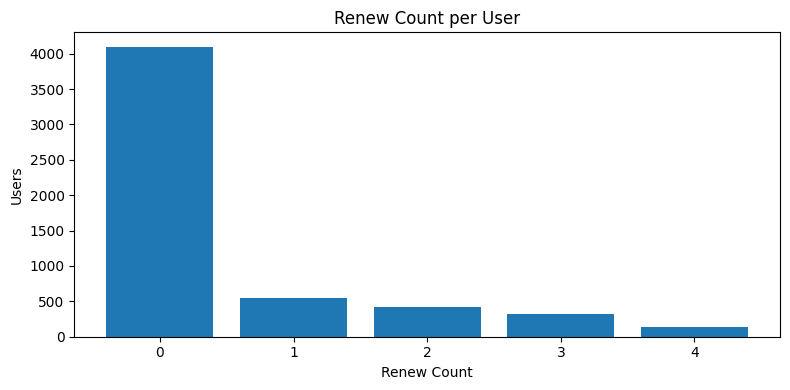

,users
is_renew,
0,4097
1,548
2,420
3,318
4,137


In [148]:
# user_id별 renew 횟수 (action == 'renew')
renew_counts = (
    plan_history
    .assign(is_renew=plan_history["action"].eq("renew"))
    .groupby("user_id")["is_renew"]
    .sum()
)

# renew 횟수 분포 (예: 1개 00건)
dist = renew_counts.value_counts().sort_index()

# 시각화
plt.figure(figsize=(8, 4))
plt.bar(dist.index.astype(str), dist.values)
plt.title("Renew Count per User")
plt.xlabel("Renew Count")
plt.ylabel("Users")
plt.tight_layout()
plt.show()

# 표로 확인
dist.rename("users").to_frame()


In [149]:
# plan_name 별 renew 건수
renew_by_plan = (
    plan_history
    .loc[plan_history["action"].eq("renew")]
    .groupby("plan_name")
    .size()
    .sort_values(ascending=False)
)

renew_by_plan.rename("renew_count").to_frame()


,renew_count
plan_name,
monthly_basic,1692
monthly_pro,1198


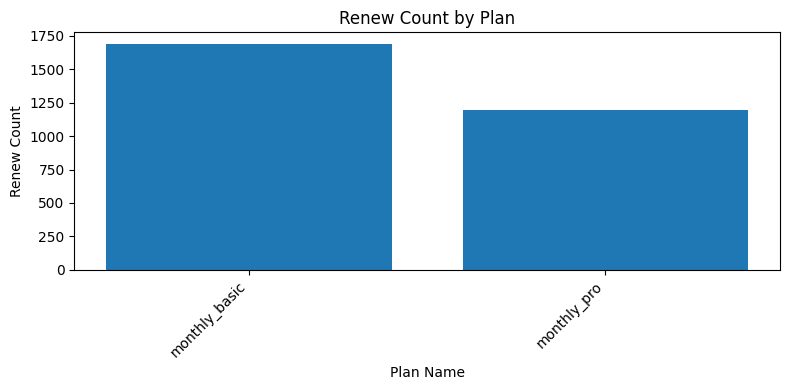

In [150]:
# 표
renew_by_plan.rename("renew_count").to_frame()

# 시각화
plt.figure(figsize=(8, 4))
plt.bar(renew_by_plan.index, renew_by_plan.values)
plt.title("Renew Count by Plan")
plt.xlabel("Plan Name")
plt.ylabel("Renew Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


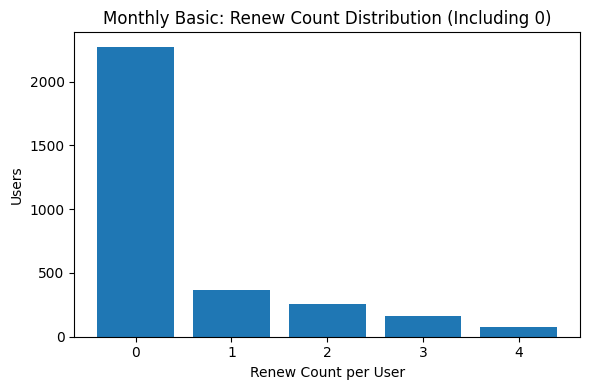

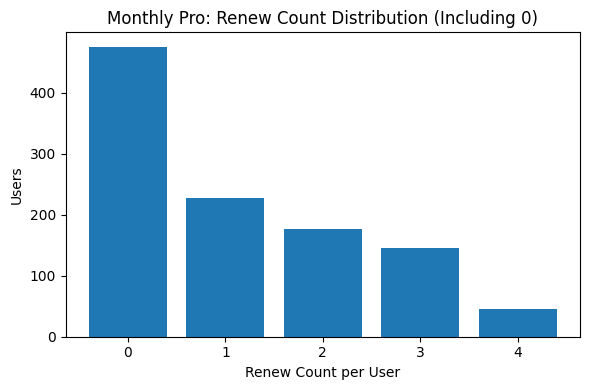

In [151]:
import matplotlib.pyplot as plt
import pandas as pd

def renew_dist_by_plan_including_zero(plan):
    # 이 플랜에 한번이라도 등장한 유저 전체
    users = plan_history.loc[plan_history["plan_name"].eq(plan), "user_id"].unique()
    base = pd.Series(users, name="user_id")

    # 해당 플랜 renew 횟수
    renew_counts = (
        plan_history
        .loc[plan_history["action"].eq("renew") & plan_history["plan_name"].eq(plan)]
        .groupby("user_id")
        .size()
    )

    # 0 포함
    counts = base.map(renew_counts).fillna(0).astype(int)

    # 분포
    return counts.value_counts().sort_index()

def plot_dist(dist, title):
    plt.figure(figsize=(6, 4))
    plt.bar(dist.index.astype(str), dist.values)
    plt.title(title)
    plt.xlabel("Renew Count per User")
    plt.ylabel("Users")
    plt.tight_layout()
    plt.show()

monthly_basic_dist = renew_dist_by_plan_including_zero("monthly_basic")
monthly_pro_dist   = renew_dist_by_plan_including_zero("monthly_pro")

# 표
monthly_basic_dist.rename("users").to_frame()
monthly_pro_dist.rename("users").to_frame()

# 시각화
plot_dist(monthly_basic_dist, "Monthly Basic: Renew Count Distribution (Including 0)")
plot_dist(monthly_pro_dist, "Monthly Pro: Renew Count Distribution (Including 0)")


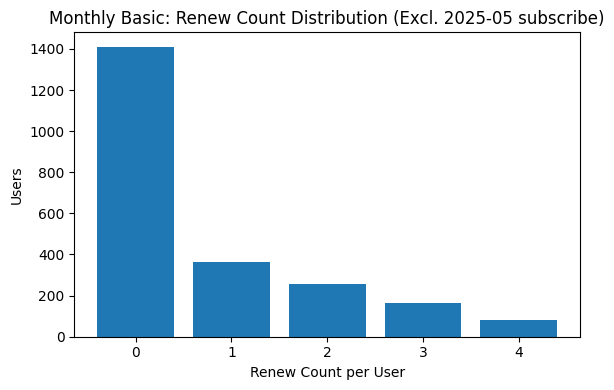

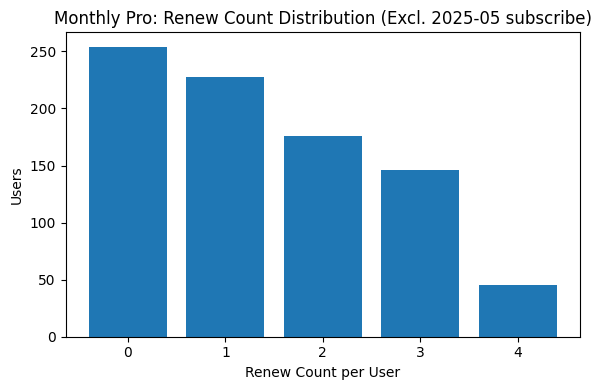

In [152]:
import matplotlib.pyplot as plt
import pandas as pd

ph = plan_history.copy()
ph["action_date"] = pd.to_datetime(ph["action_date"], errors="coerce")

# 2025-05의 subscribe만 제외
ph = ph.loc[~(
    ph["action"].eq("subscribe") &
    ph["action_date"].dt.to_period("M").eq("2025-05")
)]

def renew_dist_by_plan_including_zero(plan):
    users = ph.loc[ph["plan_name"].eq(plan), "user_id"].unique()
    base = pd.Series(users, name="user_id")

    renew_counts = (
        ph.loc[ph["action"].eq("renew") & ph["plan_name"].eq(plan)]
          .groupby("user_id")
          .size()
    )

    counts = base.map(renew_counts).fillna(0).astype(int)
    return counts.value_counts().sort_index()

def plot_dist(dist, title):
    plt.figure(figsize=(6, 4))
    plt.bar(dist.index.astype(str), dist.values)
    plt.title(title)
    plt.xlabel("Renew Count per User")
    plt.ylabel("Users")
    plt.tight_layout()
    plt.show()

monthly_basic_dist = renew_dist_by_plan_including_zero("monthly_basic")
monthly_pro_dist   = renew_dist_by_plan_including_zero("monthly_pro")

monthly_basic_dist.rename("users").to_frame()
monthly_pro_dist.rename("users").to_frame()

plot_dist(monthly_basic_dist, "Monthly Basic: Renew Count Distribution (Excl. 2025-05 subscribe)")
plot_dist(monthly_pro_dist, "Monthly Pro: Renew Count Distribution (Excl. 2025-05 subscribe)")


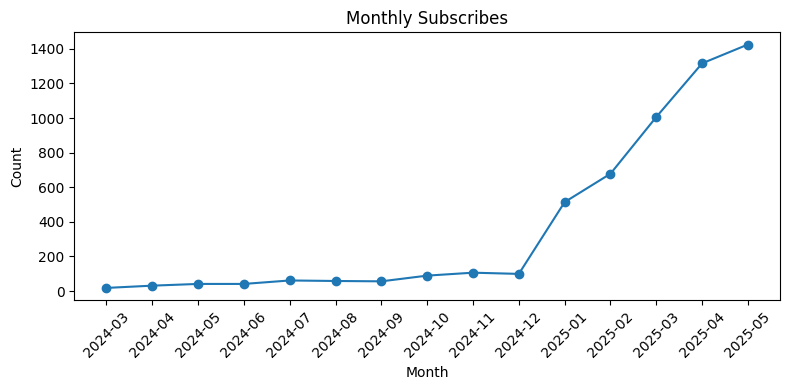

In [153]:
# 월별 subscribe 집계 (plan_history 기준)
df = plan_history.copy()
df["action_date"] = pd.to_datetime(df["action_date"], errors="coerce")

monthly = (
    df.loc[df["action"].eq("subscribe")]
      .assign(month=df["action_date"].dt.to_period("M"))
      .groupby("month")
      .size()
      .sort_index()
)

# 표
monthly.rename("subscribe_count").to_frame()

# 시각화
plt.figure(figsize=(8, 4))
plt.plot(monthly.index.astype(str), monthly.values, marker="o")
plt.title("Monthly Subscribes")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [154]:
df = plan_history.copy()

# action_date가 datetime이어야 함
df["action_date"] = pd.to_datetime(df["action_date"], errors="coerce")

df = df.loc[df["action_date"] >= "2025-01-01"]
df = df.loc[~df["plan_name"].str.contains("annual", case=False, na=False)]


In [155]:
# df는 앞에서 필터링된 데이터프레임이라고 가정
# (2025년 이후 + annual 제외)

monthly_by_plan = (
    df.loc[df["action"].eq("subscribe")]
      .assign(month=df["action_date"].dt.to_period("M"))
      .groupby(["plan_name", "month"])
      .size()
      .rename("subscribe_count")
      .reset_index()
      .sort_values(["plan_name", "month"])
)

monthly_by_plan


,plan_name,month,subscribe_count
0,monthly_basic,2025-01,292
1,monthly_basic,2025-02,394
2,monthly_basic,2025-03,581
3,monthly_basic,2025-04,787
4,monthly_basic,2025-05,863
5,monthly_pro,2025-01,92
6,monthly_pro,2025-02,138
7,monthly_pro,2025-03,186
8,monthly_pro,2025-04,209
9,monthly_pro,2025-05,222


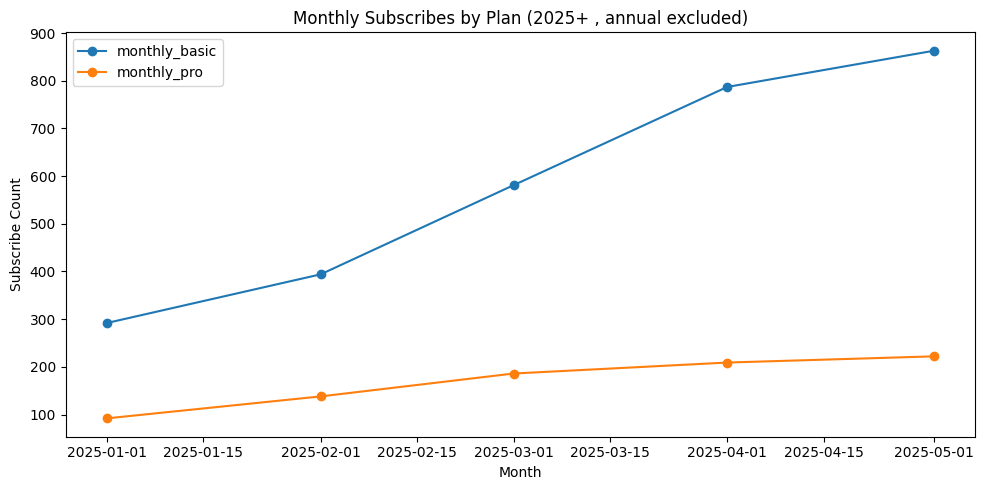

In [156]:
import matplotlib.pyplot as plt

# df는 앞에서 필터링된 데이터프레임이라고 가정
monthly_by_plan = (
    df.loc[df["action"].eq("subscribe")]
      .assign(month=df["action_date"].dt.to_period("M").dt.to_timestamp())
      .groupby(["plan_name", "month"])
      .size()
      .rename("subscribe_count")
      .reset_index()
      .sort_values(["plan_name", "month"])
)

# plan별 라인 차트
plt.figure(figsize=(10, 5))
for plan, g in monthly_by_plan.groupby("plan_name"):
    plt.plot(g["month"], g["subscribe_count"], marker="o", label=plan)

plt.title("Monthly Subscribes by Plan (2025+ , annual excluded)")
plt.xlabel("Month")
plt.ylabel("Subscribe Count")
plt.legend()
plt.tight_layout()
plt.show()


In [157]:
# plan_name별, user별 renew 건수 (0부터 포함)
users_by_plan = df[["plan_name","user_id"]].drop_duplicates()

renew_counts = (
    df.loc[df["action"].eq("renew")]
    .groupby(["plan_name","user_id"])
    .size()
    .rename("renew_count")
    .reset_index()
)

plan_user_renew = (
    users_by_plan
    .merge(renew_counts, on=["plan_name","user_id"], how="left")
    .fillna({"renew_count": 0})
)

plan_user_renew  # long format



,plan_name,user_id,renew_count
0,monthly_basic,U-00110,0.0
1,monthly_basic,U-00210,0.0
2,monthly_pro,U-00256,0.0
3,monthly_basic,U-00673,0.0
4,monthly_basic,U-00947,0.0
...,...,...,...
3823,monthly_basic,U-17848,0.0
3824,monthly_pro,U-17849,0.0
3825,monthly_pro,U-17855,0.0
3826,monthly_basic,U-17856,0.0


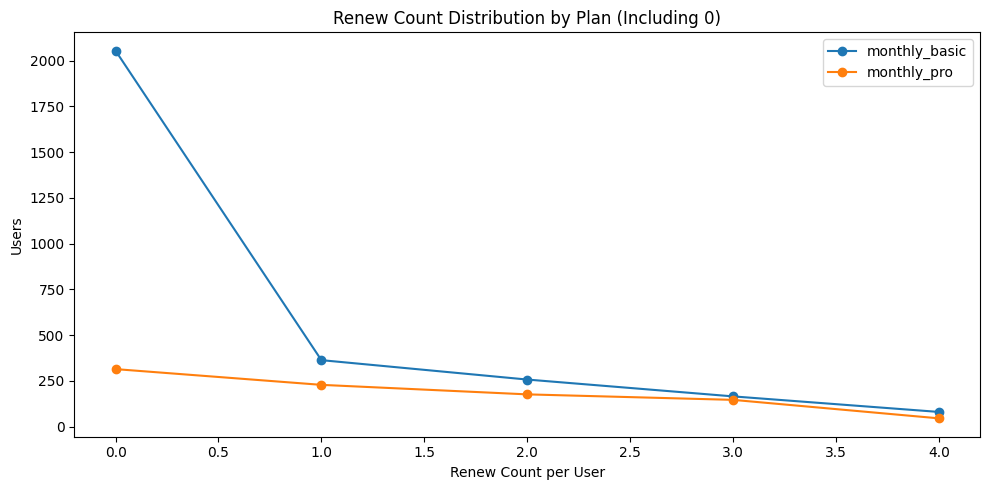

In [158]:
# 분포 시각화 (plan별)
dist = (
    plan_user_renew
    .groupby(["plan_name","renew_count"])
    .size()
    .rename("users")
    .reset_index()
)

plt.figure(figsize=(10, 5))
for plan, g in dist.groupby("plan_name"):
    plt.plot(g["renew_count"], g["users"], marker="o", label=plan)

plt.title("Renew Count Distribution by Plan (Including 0)")
plt.xlabel("Renew Count per User")
plt.ylabel("Users")
plt.legend()
plt.tight_layout()
plt.show()



In [159]:
# upgrade만 필터
up = plan_history.loc[plan_history["action"].eq("upgrade")].copy()

# 1) 업그레이드 총 건수
upgrade_total = len(up)

# 2) 업그레이드된 플랜 분포
upgrade_by_plan = up["plan_name"].value_counts()

# 3) 이전 플랜이 있으면 from->to 매트릭스
# (previous_plan 컬럼이 있을 때)
if "previous_plan" in up.columns:
    upgrade_from_to = (
        up.groupby(["previous_plan", "plan_name"])
          .size()
          .rename("count")
          .reset_index()
          .sort_values("count", ascending=False)
    )
else:
    upgrade_from_to = None

# 4) 월별 업그레이드 추이 (action_date 필요)
up["action_date"] = pd.to_datetime(up["action_date"], errors="coerce")
upgrade_monthly = (
    up.assign(month=up["action_date"].dt.to_period("M"))
      .groupby("month")
      .size()
      .sort_index()
)

upgrade_total, upgrade_by_plan, upgrade_from_to, upgrade_monthly


(63,
 plan_name
 monthly_pro    63
 Name: count, dtype: int64,
    previous_plan    plan_name  count
 0  monthly_basic  monthly_pro     63,
 month
 2025-02     3
 2025-03    17
 2025-04    19
 2025-05    24
 Freq: M, dtype: int64)

In [160]:
# 2) 월별, plan_name 별 subscribe 건수 (plan_history 기준)
ph = plan_history.copy()
ph["action_date"] = pd.to_datetime(ph["action_date"], errors="coerce")

monthly_by_plan = (
    ph.loc[ph["action"].eq("subscribe")]
      .assign(month=ph["action_date"].dt.to_period("M"))
      .groupby(["plan_name", "month"])
      .size()
      .rename("subscribe_count")
      .reset_index()
      .sort_values(["plan_name", "month"])
)

monthly_by_plan


,plan_name,month,subscribe_count
0,annual_basic,2024-03,3
1,annual_basic,2024-04,7
2,annual_basic,2024-05,5
3,annual_basic,2024-06,11
4,annual_basic,2024-07,14
5,annual_basic,2024-08,13
6,annual_basic,2024-09,10
7,annual_basic,2024-10,16
8,annual_basic,2024-11,17
9,annual_basic,2024-12,16


In [161]:
import pandas as pd

ph = plan_history.copy()
ph["action_date"] = pd.to_datetime(ph["action_date"], errors="coerce")

# 1) 구독 코호트 (subscribe 월)
subs = ph.loc[ph["action"].eq("subscribe"), ["user_id", "action_date"]].dropna()
subs["cohort_month"] = subs["action_date"].dt.to_period("M")

# 2) 다음 달에 renew 또는 subscribe가 있으면 유지
ret_actions = ph.loc[ph["action"].isin(["renew", "subscribe"]), ["user_id", "action_date"]].dropna()
ret_actions["action_month"] = ret_actions["action_date"].dt.to_period("M")

# 3) 코호트별 1개월 리텐션 계산
subs["next_month"] = subs["cohort_month"] + 1

retained = subs.merge(
    ret_actions,
    left_on=["user_id", "next_month"],
    right_on=["user_id", "action_month"],
    how="left",
    indicator=True
)

cohort_retention = (
    retained.assign(retained=retained["_merge"].eq("both"))
            .groupby("cohort_month")
            .agg(
                cohort_size=("user_id", "nunique"),
                retained_users=("retained", "sum")
            )
)

cohort_retention["retention_rate"] = (
    cohort_retention["retained_users"] / cohort_retention["cohort_size"] * 100
)

cohort_retention


,cohort_size,retained_users,retention_rate
cohort_month,,,
2024-03,18,0,0.000000
2024-04,31,0,0.000000
2024-05,41,0,0.000000
2024-06,41,0,0.000000
2024-07,61,0,0.000000
2024-08,58,0,0.000000
2024-09,56,0,0.000000
2024-10,89,0,0.000000
2024-11,106,0,0.000000


In [172]:
funnel_df

,stage,user_cnt
0,signup_completed,14050
1,lesson_started,11495
2,lesson_completed,10926
3,pricing_page_viewed,8209
4,plan_selected,5223
5,subscribe,3915


In [184]:
funnel_join2 = pd.read_csv(path + r'/funnel_join2.csv')

In [185]:
import pandas as pd

df = funnel_join2.copy()
df["event_timestamp"] = pd.to_datetime(df["event_timestamp"], errors="coerce")

steps = [
    "session_started",
    "signup_completed",
    "course_detail_viewed",
    "lesson_started",
    "lesson_completed",
    "pricing_page_viewed",
    "checkout_started",
    "plan_selected",
]

# 각 단계 수행한 유저
step_users = {
    step: set(df.loc[df["event_name"].eq(step), "user_id"].dropna().unique())
    for step in steps
}

# 깔때기: 이전 단계까지 모두 수행한 유저만 유지
funnel_users = {}
current = step_users[steps[0]].copy()
funnel_users[steps[0]] = current

for step in steps[1:]:
    current = current & step_users[step]
    funnel_users[step] = current

# 단계별 유저 수
funnel_counts = pd.DataFrame({
    "step": steps,
    "users": [len(funnel_users[s]) for s in steps]
})

funnel_counts


,step,users
0,session_started,14050
1,signup_completed,14050
2,course_detail_viewed,10299
3,lesson_started,9304
4,lesson_completed,9046
5,pricing_page_viewed,6348
6,checkout_started,2285
7,plan_selected,2285


In [187]:
import pandas as pd
import plotly.express as px

df = funnel_join2.copy()
df["event_timestamp"] = pd.to_datetime(df["event_timestamp"], errors="coerce")

steps = [
    "session_started",
    "signup_completed",
    "course_detail_viewed",
    "lesson_started",
    "lesson_completed",
    "pricing_page_viewed",
    "checkout_started",
    "plan_selected",
]

# 각 단계 수행한 유저
step_users = {
    step: set(df.loc[df["event_name"].eq(step), "user_id"].dropna().unique())
    for step in steps
}

# 깔때기: 이전 단계까지 모두 수행한 유저만 유지
current = step_users[steps[0]].copy()
funnel_counts = []

funnel_counts.append([steps[0], len(current)])
for step in steps[1:]:
    current = current & step_users[step]
    funnel_counts.append([step, len(current)])

funnel_counts = pd.DataFrame(funnel_counts, columns=["step", "users"])

# 퍼널 차트
fig = px.funnel(funnel_counts, x="users", y="step")
fig.update_layout(title="Strict Funnel (All Previous Steps Required)")
fig.show()


In [188]:
import pandas as pd
import plotly.express as px

df = funnel_join2.copy()
df["event_timestamp"] = pd.to_datetime(df["event_timestamp"], errors="coerce")

steps = [
    "signup_completed",
    "lesson_started",
    "lesson_completed",
    "pricing_page_viewed",
    "checkout_started",
    "plan_selected",
]

# 각 단계 수행한 유저
step_users = {
    step: set(df.loc[df["event_name"].eq(step), "user_id"].dropna().unique())
    for step in steps
}

# 깔때기: 이전 단계까지 모두 수행한 유저만 유지
current = step_users[steps[0]].copy()
funnel_counts = []

funnel_counts.append([steps[0], len(current)])
for step in steps[1:]:
    current = current & step_users[step]
    funnel_counts.append([step, len(current)])

funnel_counts = pd.DataFrame(funnel_counts, columns=["step", "users"])

# 퍼널 차트
fig = px.funnel(funnel_counts, x="users", y="step")
fig.update_layout(title="Strict Funnel: signup → plan_selected")
fig.show()


In [191]:
import pandas as pd
import plotly.express as px

df = funnel_join2.copy()
df["event_timestamp"] = pd.to_datetime(df["event_timestamp"], errors="coerce")

steps = [
    "session_started",
    "onboarding_started",
    "onboarding_step_completed",
    "onboarding_completed",
    "lesson_started",
    "lesson_completed",
    "pricing_page_viewed",
    "checkout_started",
    "plan_selected",
]

# 각 단계 수행한 유저
step_users = {
    step: set(df.loc[df["event_name"].eq(step), "user_id"].dropna().unique())
    for step in steps
}

# 깔때기: 이전 단계까지 모두 수행한 유저만 유지
current = step_users[steps[0]].copy()
funnel_counts = []

funnel_counts.append([steps[0], len(current)])
for step in steps[1:]:
    current = current & step_users[step]
    funnel_counts.append([step, len(current)])

funnel_counts = pd.DataFrame(funnel_counts, columns=["step", "users"])

# 퍼널 차트
fig = px.funnel(funnel_counts, x="users", y="step")
fig.update_layout(title="Strict Funnel: session → lesson_started")
fig.show()


In [192]:
import pandas as pd
import plotly.express as px

df = funnel_join2.copy()
df["event_timestamp"] = pd.to_datetime(df["event_timestamp"], errors="coerce")

steps = [
    "lesson_started",
    "lesson_completed",
    "quiz_submitted",
    "course_completed",
    "certificate_downloaded",
]

# 각 단계 수행한 유저
step_users = {
    step: set(df.loc[df["event_name"].eq(step), "user_id"].dropna().unique())
    for step in steps
}

# 깔때기: 이전 단계까지 모두 수행한 유저만 유지
current = step_users[steps[0]].copy()
funnel_counts = []

funnel_counts.append([steps[0], len(current)])
for step in steps[1:]:
    current = current & step_users[step]
    funnel_counts.append([step, len(current)])

funnel_counts = pd.DataFrame(funnel_counts, columns=["step", "users"])

# 퍼널 차트
fig = px.funnel(funnel_counts, x="users", y="step")
fig.update_layout(title="Strict Funnel: lesson → certificate")
fig.show()


In [193]:
import pandas as pd
import plotly.express as px

df = funnel_join2.copy()
df["event_timestamp"] = pd.to_datetime(df["event_timestamp"], errors="coerce")

steps = [
    "session_started",
    "signup_completed",
    "course_detail_viewed",
    "lesson_started",
    "lesson_completed",
    "plan_selected",
]

# 각 단계 수행한 유저
step_users = {
    step: set(df.loc[df["event_name"].eq(step), "user_id"].dropna().unique())
    for step in steps
}

# 깔때기: 이전 단계까지 모두 수행한 유저만 유지
current = step_users[steps[0]].copy()
funnel_counts = []

funnel_counts.append([steps[0], len(current)])
for step in steps[1:]:
    current = current & step_users[step]
    funnel_counts.append([step, len(current)])

funnel_counts = pd.DataFrame(funnel_counts, columns=["step", "users"])

# 퍼널 차트
fig = px.funnel(funnel_counts, x="users", y="step")
fig.update_layout(title="Strict Funnel: session → plan_selected")
fig.show()


In [221]:
import pandas as pd
import plotly.express as px
from plotly.subplots import make_subplots

df = funnel_join2.copy()
df["event_timestamp"] = pd.to_datetime(df["event_timestamp"], errors="coerce")

funnels = [
    ("F1: session→plan", [
        "signup_completed",
        "lesson_started","lesson_completed","pricing_page_viewed",
        "plan_selected","checkout_started","subscribe"
    ]),
    ("F2: signup→plan", [
        "signup_completed","lesson_started","lesson_completed",
        "pricing_page_viewed","plan_selected","checkout_started"
    ]),
    ("F3: onboarding→lesson", [
        "signup_completed","onboarding_started","onboarding_step_completed",
        "onboarding_completed","lesson_started","checkout_started"
    ]),
    ("F4: lesson→certificate", [
        "lesson_started","lesson_completed","quiz_submitted",
        "course_completed","certificate_downloaded"
    ]),
    ("F5: session→plan (short)", [
        "session_started","signup_completed","course_detail_viewed",
        "lesson_started","lesson_completed","plan_selected"
    ]),
]

def strict_funnel_counts(steps):
    step_users = {
        step: set(df.loc[df["event_name"].eq(step), "user_id"].dropna().unique())
        for step in steps
    }
    current = step_users[steps[0]].copy()
    counts = [(steps[0], len(current))]
    for step in steps[1:]:
        current = current & step_users[step]
        counts.append((step, len(current)))
    return pd.DataFrame(counts, columns=["step", "users"])

rows = 5
cols = 1
fig = make_subplots(
    rows=rows, cols=cols,
    subplot_titles=[name for name, _ in funnels]
)

for i, (name, steps) in enumerate(funnels, start=1):
    r = (i - 1) // cols + 1
    c = (i - 1) % cols + 1
    f = strict_funnel_counts(steps)
    trace = px.funnel(f, x="users", y="step").data[0]
    fig.add_trace(trace, row=r, col=c)

fig.update_layout(
    height=2500,
    width=1200,
    title="All Funnels (Strict)",
    showlegend=False
)
fig.show()


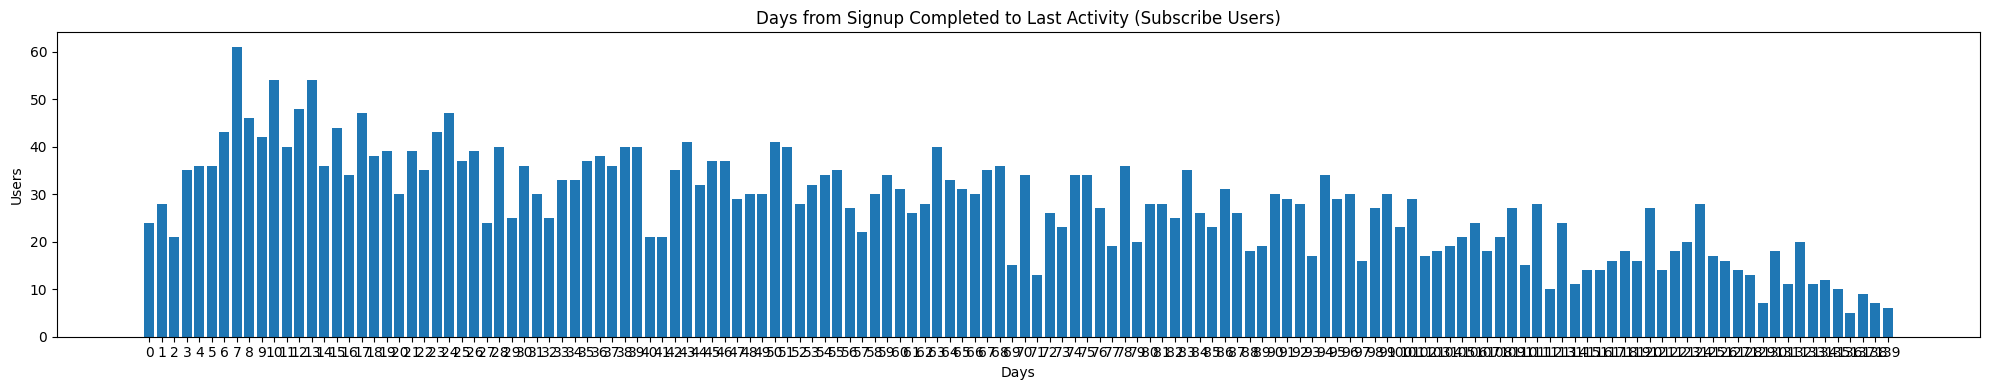

In [210]:
import pandas as pd
import matplotlib.pyplot as plt

df = funnel_join2.copy()
df["event_timestamp"] = pd.to_datetime(df["event_timestamp"], errors="coerce")

# subscribe 유저만 필터
sub_users = df.loc[df["event_name"].eq("subscribe"), "user_id"].dropna().unique()

# 가입 완료 시점(유저별 최초)
signup = (
    df.loc[df["event_name"].eq("signup_completed")]
      .groupby("user_id")["event_timestamp"]
      .min()
      .rename("signup_ts")
)

# 마지막 활동 시점(유저별 최종 이벤트)
last_act = (
    df.groupby("user_id")["event_timestamp"]
      .max()
      .rename("last_ts")
)

# 가입 완료 + subscribe 유저만
u = pd.concat([signup, last_act], axis=1).dropna()
u = u.loc[u.index.isin(sub_users)]

# 가입 이후 마지막 활동까지 일수
u["days_active"] = (u["last_ts"] - u["signup_ts"]).dt.days.clip(lower=0)

# 일수 분포
dist = u["days_active"].value_counts().sort_index()

# 표
dist.rename("users").to_frame()

# 시각화
plt.figure(figsize=(20, 4))
plt.bar(dist.index.astype(str), dist.values)
plt.title("Days from Signup Completed to Last Activity (Subscribe Users)")
plt.xlabel("Days")
plt.ylabel("Users")
plt.tight_layout()
plt.show()


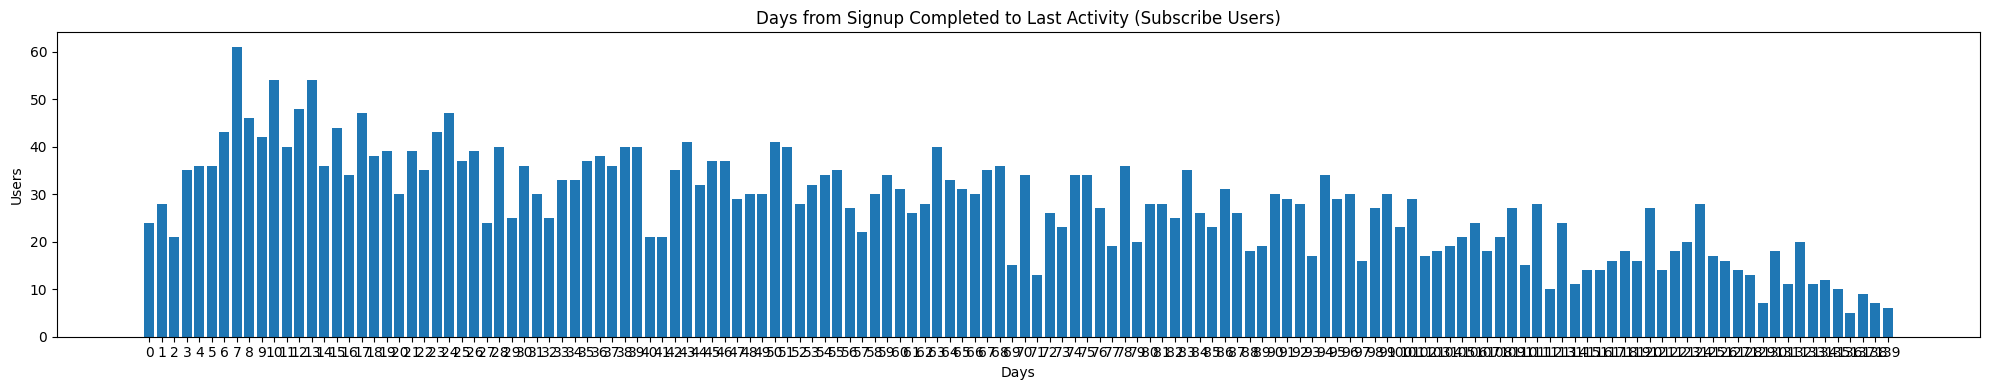

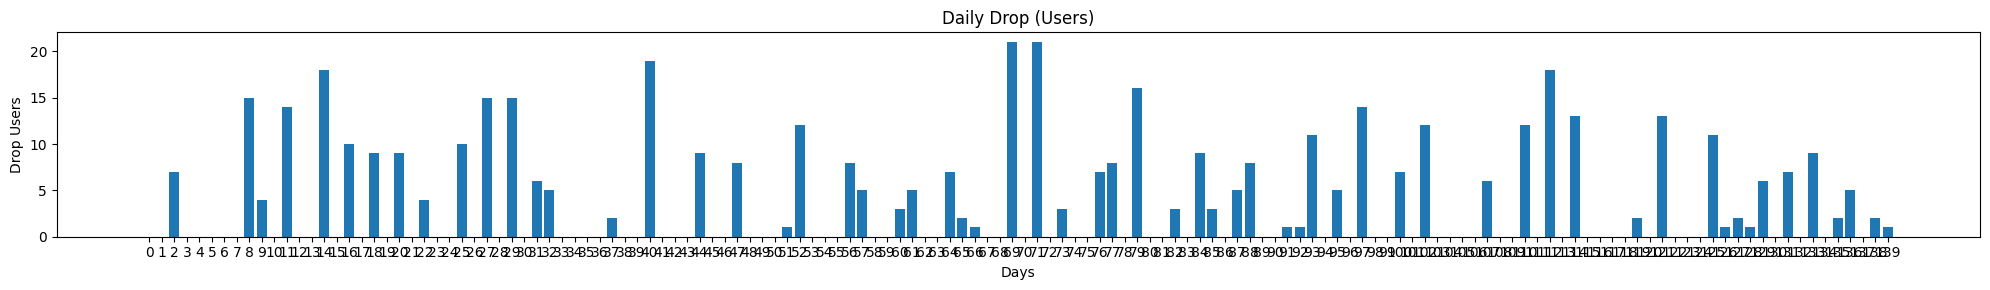

(69,
 np.float64(21.0),
              drop_users
 days_active            
 69                 21.0
 71                 21.0
 40                 19.0
 14                 18.0
 112                18.0
 79                 16.0
 27                 15.0
 29                 15.0
 8                  15.0
 11                 14.0)

In [211]:
import pandas as pd
import matplotlib.pyplot as plt

# dist는 이미 계산된 일수 분포 Series (index=days, value=users)라고 가정
# 없으면 아래 주석 해제해서 dist 계산
# dist = u["days_active"].value_counts().sort_index()

# 0~최대일까지 빈 구간 0으로 채우기
dist_full = dist.reindex(range(dist.index.min(), dist.index.max() + 1), fill_value=0)

# 일별 변화량(감소 폭)
delta = dist_full.diff().fillna(0)
drop = -delta
drop[drop < 0] = 0  # 감소만

# 1) 가장 큰 급락 구간
max_drop_day = drop.idxmax()
max_drop_value = drop.loc[max_drop_day]

# 2) 상위 급락 구간 (예: 상위 10개)
top_drops = drop.sort_values(ascending=False).head(10).rename("drop_users").to_frame()

# 시각화: 분포 + 급락 표시
plt.figure(figsize=(20, 4))
plt.bar(dist_full.index.astype(str), dist_full.values)
plt.title("Days from Signup Completed to Last Activity (Subscribe Users)")
plt.xlabel("Days")
plt.ylabel("Users")
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 3))
plt.bar(drop.index.astype(str), drop.values)
plt.title("Daily Drop (Users)")
plt.xlabel("Days")
plt.ylabel("Drop Users")
plt.tight_layout()
plt.show()

max_drop_day, max_drop_value, top_drops


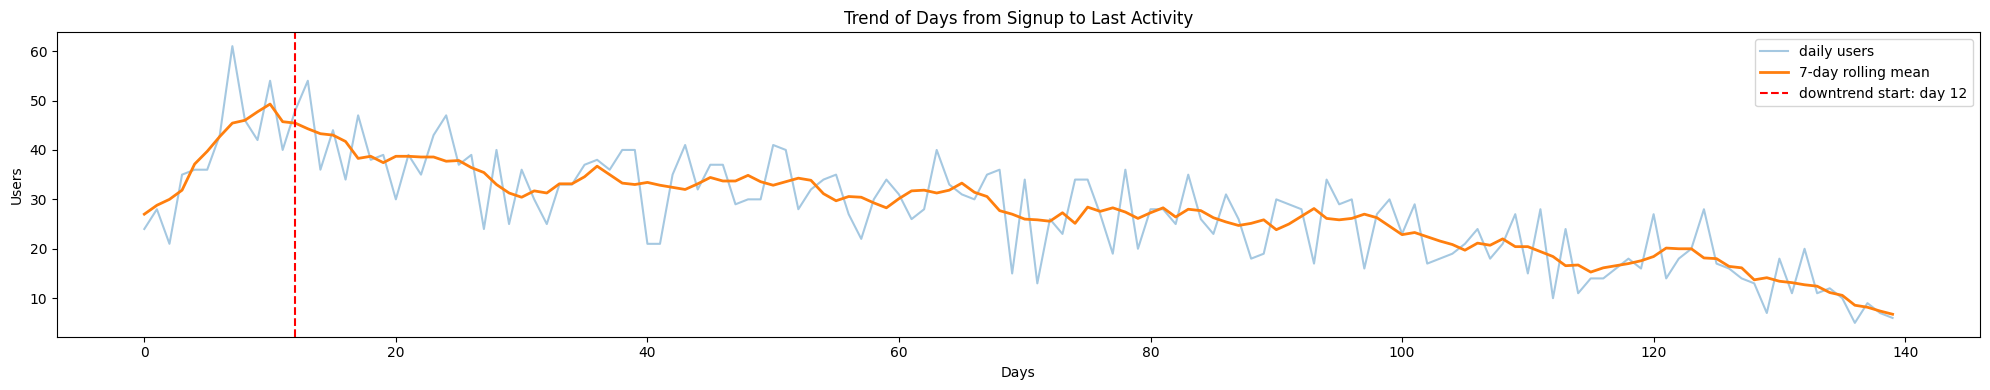

In [220]:
# dist는 이미 계산된 일수 분포 Series (index=days, value=users)
dist_full = dist.reindex(range(dist.index.min(), dist.index.max() + 1), fill_value=0)

# 1) 롤링 평균으로 추세 확인
window = 7
roll = dist_full.rolling(window, center=True, min_periods=1).mean()

# 2) 롤링 평균 기울기(일별 변화)
slope = roll.diff()

# 3) 감소 추세 시작점: 연속 k일 이상 음수 기울기
k = 2
is_down = slope < 0
down_streak = is_down.rolling(k).sum()

trend_start = down_streak[down_streak >= k].index.min()

# 결과
trend_start, slope.loc[trend_start:trend_start+10] if pd.notna(trend_start) else None

# 시각화
plt.figure(figsize=(20, 4))
plt.plot(dist_full.index, dist_full.values, label="daily users", alpha=0.4)
plt.plot(roll.index, roll.values, label=f"{window}-day rolling mean", linewidth=2)
if pd.notna(trend_start):
    plt.axvline(trend_start, color="red", linestyle="--", label=f"downtrend start: day {trend_start}")
plt.title("Trend of Days from Signup to Last Activity")
plt.xlabel("Days")
plt.ylabel("Users")
plt.legend()
plt.tight_layout()
plt.show()

In [216]:
# 참고: 감소 추세 구간 목록(연속 k일 이상 감소)
downtrend_periods = down_streak[down_streak >= k].index.tolist()
downtrend_periods[:20]  # 필요시 확인


[17, 72, 136, 137, 138, 139]

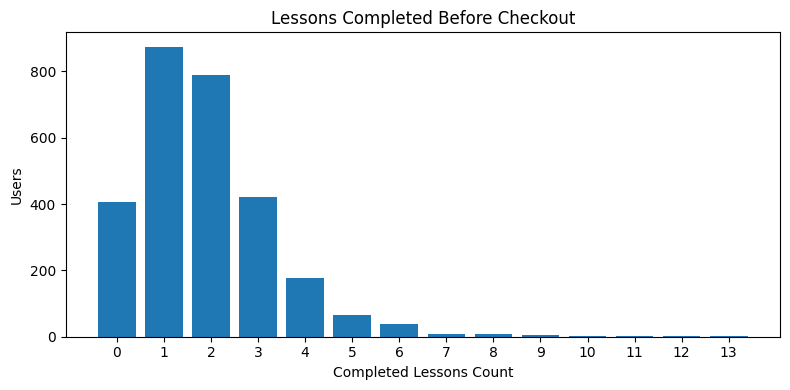

,users
0,407
1,874
2,789
3,421
4,176
5,66
6,37
7,8
8,9
9,4


In [207]:
df = funnel_join2.copy()
df["event_timestamp"] = pd.to_datetime(df["event_timestamp"], errors="coerce")

# 1) checkout_started 유저들의 "결제 이전" 강의 수강(완료) 건수
first_checkout = (
    df.loc[df["event_name"].eq("checkout_started")]
      .groupby("user_id")["event_timestamp"]
      .min()
      .rename("checkout_ts")
)

lesson_completed = df.loc[df["event_name"].eq("lesson_completed"), ["user_id", "event_timestamp"]]

lesson_before_checkout = (
    lesson_completed
    .merge(first_checkout, on="user_id", how="inner")
    .loc[lambda x: x["event_timestamp"] < x["checkout_ts"]]
    .groupby("user_id")
    .size()
    .rename("lessons_completed_before_checkout")
)

# 모든 checkout 유저 기준으로 0 포함
all_checkout_users = first_checkout.index
lesson_counts = (
    pd.Series(0, index=all_checkout_users)
      .add(lesson_before_checkout, fill_value=0)
      .astype(int)
)

lesson_dist = lesson_counts.value_counts().sort_index()

# 시각화
plt.figure(figsize=(8,4))
plt.bar(lesson_dist.index.astype(str), lesson_dist.values)
plt.title("Lessons Completed Before Checkout")
plt.xlabel("Completed Lessons Count")
plt.ylabel("Users")
plt.tight_layout()
plt.show()

lesson_dist.rename("users").to_frame()


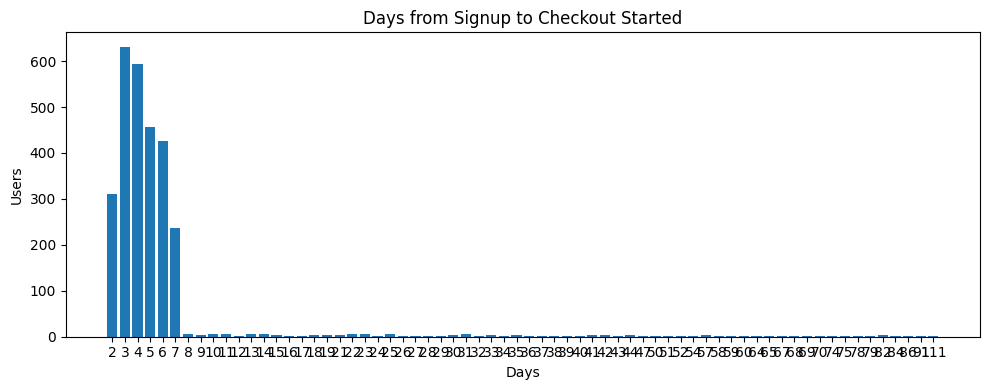

,users
days,
2,310
3,631
4,594
5,456
6,426
...,...
82,4
84,1
86,2


In [208]:
# 2) 회원 가입 후 몇일 차에 checkout_started 발생
signup = (
    df.loc[df["event_name"].eq("signup_completed")]
      .groupby("user_id")["event_timestamp"]
      .min()
      .rename("signup_ts")
)

days_to_checkout = (
    signup.to_frame()
      .join(first_checkout, how="inner")
      .assign(days=lambda x: (x["checkout_ts"] - x["signup_ts"]).dt.days.clip(lower=0))
      ["days"]
)

days_dist = days_to_checkout.value_counts().sort_index()

# 시각화
plt.figure(figsize=(10,4))
plt.bar(days_dist.index.astype(str), days_dist.values)
plt.title("Days from Signup to Checkout Started")
plt.xlabel("Days")
plt.ylabel("Users")
plt.tight_layout()
plt.show()

days_dist.rename("users").to_frame()
